# Deconvolution iter2 - Physics-informed residual U-Net

## iter1 결과 (실측, test 100장)

| 방법 | PSNR | SSIM |
|---|---|---|
| Measure (input) | 7.892 | 0.032 |
| **U-Net (iter1, 30 epoch, 43분)** | **25.586** | 0.878 |
| TKD (clip 5) | 31.187 | 0.934 |
| **Wiener (K=1e-4)** | **42.251** | 0.988 |

**학습된 U-Net 이 한 줄짜리 역필터보다 16.7 dB 나빴다.** iter1 의 문제는 학습량이 아니라 문제 설정이다.

- dipole forward 는 k-space 에서 **대각 연산자**이고 이 구현은 `|H|min = 2.27e-5 > 0` (분모에 `+1e-8` 이 있어 magic angle cone 이 정확히 0 이 아니다) 이라 **가역**이다.
- 즉 정답은 `x = y / H` 이고, 국소 receptive field 를 가진 CNN 이 이 전역 연산자의 역을 raw measure 로부터 처음부터 배우는 것은 가장 불리한 설계다.

## iter2 개선 항목

| # | 개선 | 근거 (로컬 재현 실험) | 기대 효과 |
|---|---|---|---|
| 1 | **정규화 세기 K 를 GCV 로 자동 선택** | K sweep: 1e-4 → 41.1, 1e-6 → 54.8, 1e-8 → 71.8, 0 → 107.2 dB. iter1 은 1e-4 에서 sweep 을 멈췄다. 단 σ=1e-4 노이즈만 있어도 K=0 은 28.9 dB 로 붕괴하므로 고정 K 는 위험하다. GCV(label 불필요)는 oracle 대비 0.3~1.1 dB 이내 | 42.3 → **47~80 dB** (학습 없이) |
| 2 | **Physics-informed 입력 6채널** | measure 단독 입력은 전역 역연산을 CNN 에 떠넘긴다. 역필터 결과를 채널로 주면 CNN 은 **국소 잔차 보정**만 하면 된다 | 학습 난이도 급감 |
| 3 | **residual + 마지막 conv zero-init** | 초기 출력이 base(analytic 복원)와 **정확히 동일** | conventional 성능에서 출발, 하한 보장 |
| 4 | **gradient 가중 Tikhonov 채널** | 노이즈 구간에서 plain Wiener 대비 +1.4~2.4 dB | 노이즈 있을 때 보강 |
| 5 | **Charbonnier + data-consistency 손실** | L2 는 이상치에 끌려가고, DC 항은 측정된 성분을 망가뜨리지 못하게 묶는다 | 안정성 |
| 6 | **AdamW + cosine LR + warmup** | iter1 은 `0.88^epoch` 지수감쇠로 마지막 lr 이 2.8e-6 (초기의 2.8%). 성능이 오르는 중에 lr 을 죽였다 | 수렴 개선 |
| 7 | **8× dihedral 증강 + 노이즈 σ 랜덤 증강** | measure 를 label 에서 즉석 생성하므로 rot90 도 유효한 pair 가 된다. 노이즈 증강은 "noise characteristic is not given" 리스크 방어 | 일반화 |
| 8 | **validation 을 `L1_*` 로 제한** | test_label 은 100장 전부 L1, val 은 L1 43 / L8 57 로 분포가 다르다 | best ckpt 선택 정합 |
| 9 | **4× flip TTA** | `dipole(flip x) = flip(dipole x)` 오차 1e-7 로 성립. rot90 은 B0 방향이 바뀌어 오차 0.67 → TTA 불가 | +0.1~0.3 dB |
| 10 | **base vs base+net 자동 선택** | 노이즈가 거의 없으면 analytic 이 이미 상한에 가깝다. validation 으로 둘 중 우수한 쪽을 고른다 | 회귀 방지 |

> iter1 에서 고친 버그(Windows basename, 복소 OTF 의 TKD clip, best ckpt 갱신 조건, PSNR mask shape 등)는 모두 반영되어 있다.


In [1]:
# Run this codeblock to mount your Google Drive in Google Colab.
from google.colab import drive

drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
# loguru 는 Colab 기본 이미지에 없으므로 필요할 때만 설치
try:
    import loguru  # noqa: F401
except ImportError:
    !pip install -q loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.1 MB/s eta 0:00:00


## 1. PSF 예시

Deconvolution: **측정 = 원본 * PSF**

PSF 3종으로 직접 blur 를 만들어 **Wiener filter** 를 적용해본다.

| PSF | 정의 | 특징 |
|---|---|---|
| Gaussian blur | 등방성 gaussian kernel | 고주파가 지수적으로 죽는다. spectrum 에 0 이 없다 |
| Motion blur | 대각선으로 길게 늘어진 gaussian (`Lecture_5_key.ipynb`) | 한 방향으로만 심하게 뭉개진다 |
| Dipole forward model | `common/dipole.py` 의 dipole kernel | k-space 에서 **magic angle (약 54.7도) 원뿔에서 0** → 그 성분은 복원 불가. 뒤에서 U-Net 이 배울 forward model |

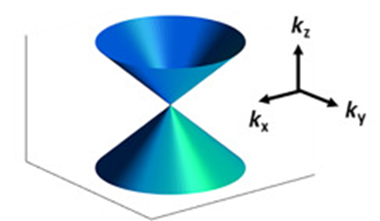

ROOT: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습
Loaded sample image: L1_00fa35a6f61da36f1c9b79cefd23baea.npy
Shape: (256, 256) | Range: [0.000, 1.000]


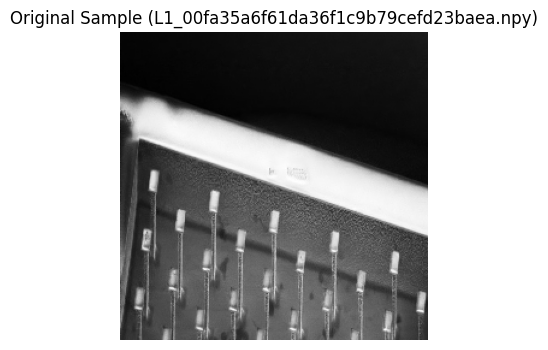

In [3]:
import glob
import json
import math
import os
import random
import time
import warnings
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from functools import lru_cache
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.io import savemat
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ROOT 자동 탐색 (Colab Drive / 로컬 모두 대응)
POSSIBLE_ROOTS = [
    Path("/content/drive/MyDrive/실습프로젝트"),
    Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습"),
    Path("/content/drive/MyDrive"),
    Path.cwd() / "ref",
    Path.cwd(),
    Path("C:/hong/project-5/ref"),
]
ROOT = POSSIBLE_ROOTS[0]
for _p in POSSIBLE_ROOTS:
    if (_p / "dataset").exists():
        ROOT = _p
        break
DATA_ROOT = ROOT / "dataset"
print(f"ROOT: {ROOT}")

# PSF 예시에 쓸 영상 한 장
train_files = (
    sorted(glob.glob(str(DATA_ROOT / "train/*.npy")))
    or sorted(glob.glob(str(DATA_ROOT / "val/*.npy")))
    or sorted(glob.glob(str(DATA_ROOT / "test_label/*.npy")))
)
if train_files:
    idx = min(10, len(train_files) - 1)
    _img = np.load(train_files[idx]).astype(np.float64)
    if _img.ndim == 3:
        _img = _img.squeeze()
    _img = (_img - _img.min()) / (_img.max() - _img.min() + 1e-8)
    example = _img[: _img.shape[0] // 2 * 2, : _img.shape[1] // 2 * 2]
    img_name = Path(train_files[idx]).name
else:
    y, x = np.mgrid[:256, :256]
    example = np.sin(x / 10.0) * np.cos(y / 10.0) * 0.5 + 0.5
    img_name = "synthetic_sample.npy"

bird = example
print(f"Loaded sample image: {img_name}")
print(f"Shape: {example.shape} | Range: [{example.min():.3f}, {example.max():.3f}]")

plt.figure(figsize=(5, 4))
plt.imshow(example, cmap="gray", vmin=0.0, vmax=1.0)
plt.title(f"Original Sample ({img_name})")
plt.axis("off")
plt.show()

## 1-1. PSF

In [4]:
def pad_psf_to_image(
    psf: np.ndarray,
    shape: tuple[int, int],
) -> np.ndarray:
    """kernel 을 영상 크기로 zero-pad (Lecture_5_key.ipynb 와 동일한 중앙 정렬)."""
    padded = np.zeros(shape, dtype=np.float64)
    a, b = shape
    c, d = psf.shape
    for i in range(c):
        for j in range(d):
            padded[
                int(np.floor(a / 2) - np.floor(c / 2) + i),
                int(np.floor(b / 2) - np.floor(d / 2) + j),
            ] = psf[i, j]
    return padded


def psf_to_otf(
    psf: np.ndarray,
    shape: tuple[int, int],
) -> np.ndarray:
    """중앙 정렬 PSF -> OTF H(u,v). ifftshift 로 kernel 중심을 원점으로 옮겨 zero-phase 로 만든다."""
    return np.fft.fft2(np.fft.ifftshift(pad_psf_to_image(psf, shape)))


def apply_otf(
    img: np.ndarray,
    otf: np.ndarray,
) -> np.ndarray:
    """measure = ifft2(fft2(img) * H). 공간 영역 convolution 과 같다 (circular)."""
    return np.real(np.fft.ifft2(np.fft.fft2(img) * otf))


def gaussian_psf(
    size: int = 21,
    sigma: float = 3.0,
) -> np.ndarray:
    """등방성 gaussian PSF."""
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax, indexing="ij")
    psf = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return psf / psf.sum()


def motion_blur_psf(
    size: int = 41,
    sigma_along: float = 12.0,
    sigma_across: float = 1.0,
) -> np.ndarray:
    """Lecture_5_key.ipynb 의 대각선 motion blur kernel.

    (+1, +1) 방향으로 길게 늘어진 gaussian. gaussian 이라 spectrum 에 zero 가 없어
    Wiener 가 안정적으로 복원할 수 있다.
    """
    kernel = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            di = i - size // 2
            dj = j - size // 2
            along = (di + dj) / np.sqrt(2)
            across = (-di + dj) / np.sqrt(2)
            kernel[i, j] = np.exp(-(along**2) / (2 * sigma_along**2) - across**2 / (2 * sigma_across**2))
    return kernel / kernel.sum()


@lru_cache(maxsize=16)
def dipole_kernel(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = (1.0, 1.0),
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> torch.Tensor:
    """common/dipole.py 원본. fftshift 가 들어 있어 반환값이 곧 OTF 다."""
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)

    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])

    D = 1 / 3 - (X * B0_dir[0] + Y * B0_dir[1]) ** 2 / (X**2 + Y**2 + 1e-8)
    D = np.fft.fftshift(D)
    D = torch.tensor(D, dtype=torch.float32)
    return D


# PSF 3종. K 는 Wiener filter 의 tunable parameter (아래 1-3 참고)
DEMO_NOISE_STD: float = 0.0  # blur 후 더할 gaussian noise 표준편차. 0 보다 크면 K 를 키워야 한다

PSF_SPECS: list[dict] = [
    {
        "key": "gaussian",
        "label": "Gaussian blur\n21x21, sigma=3",
        "psf": gaussian_psf(size=21, sigma=3.0),
        "K": 1e-6,
        "signed": False,
    },
    {
        "key": "motion",
        "label": "Motion blur (diagonal)\n41x41, sigma 12 / 1",
        "psf": motion_blur_psf(size=41, sigma_along=12.0, sigma_across=1.0),
        "K": 1e-6,
        "signed": False,
    },
    {
        "key": "dipole",
        "label": "Dipole forward model\ncommon/dipole.py",
        "psf": None,  # 공간 kernel 없이 OTF 를 직접 만든다
        "K": 1e-4,
        "signed": True,  # 결과가 음수도 가지므로 표시 스케일을 따로 잡는다
    },
]

target_sample = bird if "bird" in globals() else example
for spec in PSF_SPECS:
    if spec["psf"] is None:
        spec["otf"] = dipole_kernel(matrix_size=target_sample.shape).numpy().astype(np.float64)
    else:
        spec["otf"] = psf_to_otf(spec["psf"], target_sample.shape)
    _h = np.abs(spec["otf"])
    print(f"{spec['key']:<10} |H| min {_h.min():.2e}  max {_h.max():.3f}")

gaussian   |H| min 1.56e-11  max 1.000
motion     |H| min 1.63e-07  max 1.000
dipole     |H| min 2.27e-05  max 0.667


### 1-2. PSNR / SSIM


In [5]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(
        self,
        win_size: int = 11,
        k1: float = 0.01,
        k2: float = 0.03,
    ):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(
        self,
        img: torch.Tensor,
        ref: torch.Tensor,
        data_range: torch.Tensor,
    ) -> torch.Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        w = self.w.to(img.device)
        ux = functional.conv2d(img, w)
        uy = functional.conv2d(ref, w)
        uxx = functional.conv2d(img * img, w)
        uyy = functional.conv2d(ref * ref, w)
        uxy = functional.conv2d(img * ref, w)

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        S = (A1 * A2) / (B1 * B2)
        return torch.mean(S, dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is None:
        img_mask, ref_mask = img, ref
    else:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    return ssim_cal.forward(img_mask, ref_mask, ones)


def calculate_psnr(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None:
        if mask.dim() != IMG_DIM:
            raise ValueError("Mask must be 4D.")
        img_mask, ref_mask = img * mask, ref * mask
        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3), keepdim=True) / torch.sum(
            mask, dim=(1, 2, 3), keepdim=True
        )
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    return 10 * torch.log10(img_max**2 / (mse + 1e-12))


def psnr_ssim(
    img: np.ndarray,
    ref: np.ndarray,
) -> tuple[float, float]:
    """2차원 numpy 영상 -> (PSNR, SSIM). 위 함수들과 완전히 같은 계산이다."""

    def _t(arr: np.ndarray) -> torch.Tensor:
        return torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]

    _img, _ref = _t(img), _t(ref)
    return float(calculate_psnr(_img, _ref).item()), float(calculate_ssim(_img, _ref).mean().item())

### 1-3. Wiener filter

$$\bar I = \dfrac{1}{H}\cdot\dfrac{|H|^2}{|H|^2 + K}\hat I$$

`K`: tunable parameter

- `K = 0` 이면 순수 inverse filter (`1/H`). `H` 가 0 에 가까운 주파수에서 노이즈/수치오차가 폭발한다.
- `K` 를 키우면 `|H|^2 << K` 인 주파수를 `H/K` 로 **감쇠**시켜 폭발을 막는다. 대신 그만큼 흐려진다.
- 노이즈가 크면 `K` 도 키운다 (대략 noise 분산 / signal 분산 스케일).


In [6]:
def wiener_filter(
    measure: np.ndarray,
    otf: np.ndarray,
    K: float,
) -> np.ndarray:
    """Wiener filter: (1/H) * |H|^2 / (|H|^2 + K)."""
    h2 = np.abs(otf) ** 2
    safe_den = np.where(np.abs(otf) < 1e-12, 1e-12, otf)  # 0 나눗셈 방지
    w = (1.0 / safe_den) * (h2 / (h2 + K))
    return np.real(np.fft.ifft2(w * np.fft.fft2(measure)))


def tkd_filter(
    measure: np.ndarray,
    otf: np.ndarray,
    clip: float,
) -> np.ndarray:
    """TKD (truncated kernel division): |1/H| 를 clip 으로 제한한다.

    OTF 가 복소수(gaussian/motion blur)면 실수처럼 np.clip 을 걸 수 없다.
    np.clip 은 복소수를 실수부 우선으로 비교하므로 잘린 주파수의 **위상이 날아간다**.
    크기만 clip 하고 위상은 유지해야 한다.
    """
    safe_den = np.where(np.abs(otf) < 1e-12, 1e-12, otf)
    inv = 1.0 / safe_den
    scale = np.minimum(1.0, clip / np.maximum(np.abs(inv), 1e-12))
    return np.real(np.fft.ifft2((inv * scale) * np.fft.fft2(measure)))

### 1-4. Wiener filter


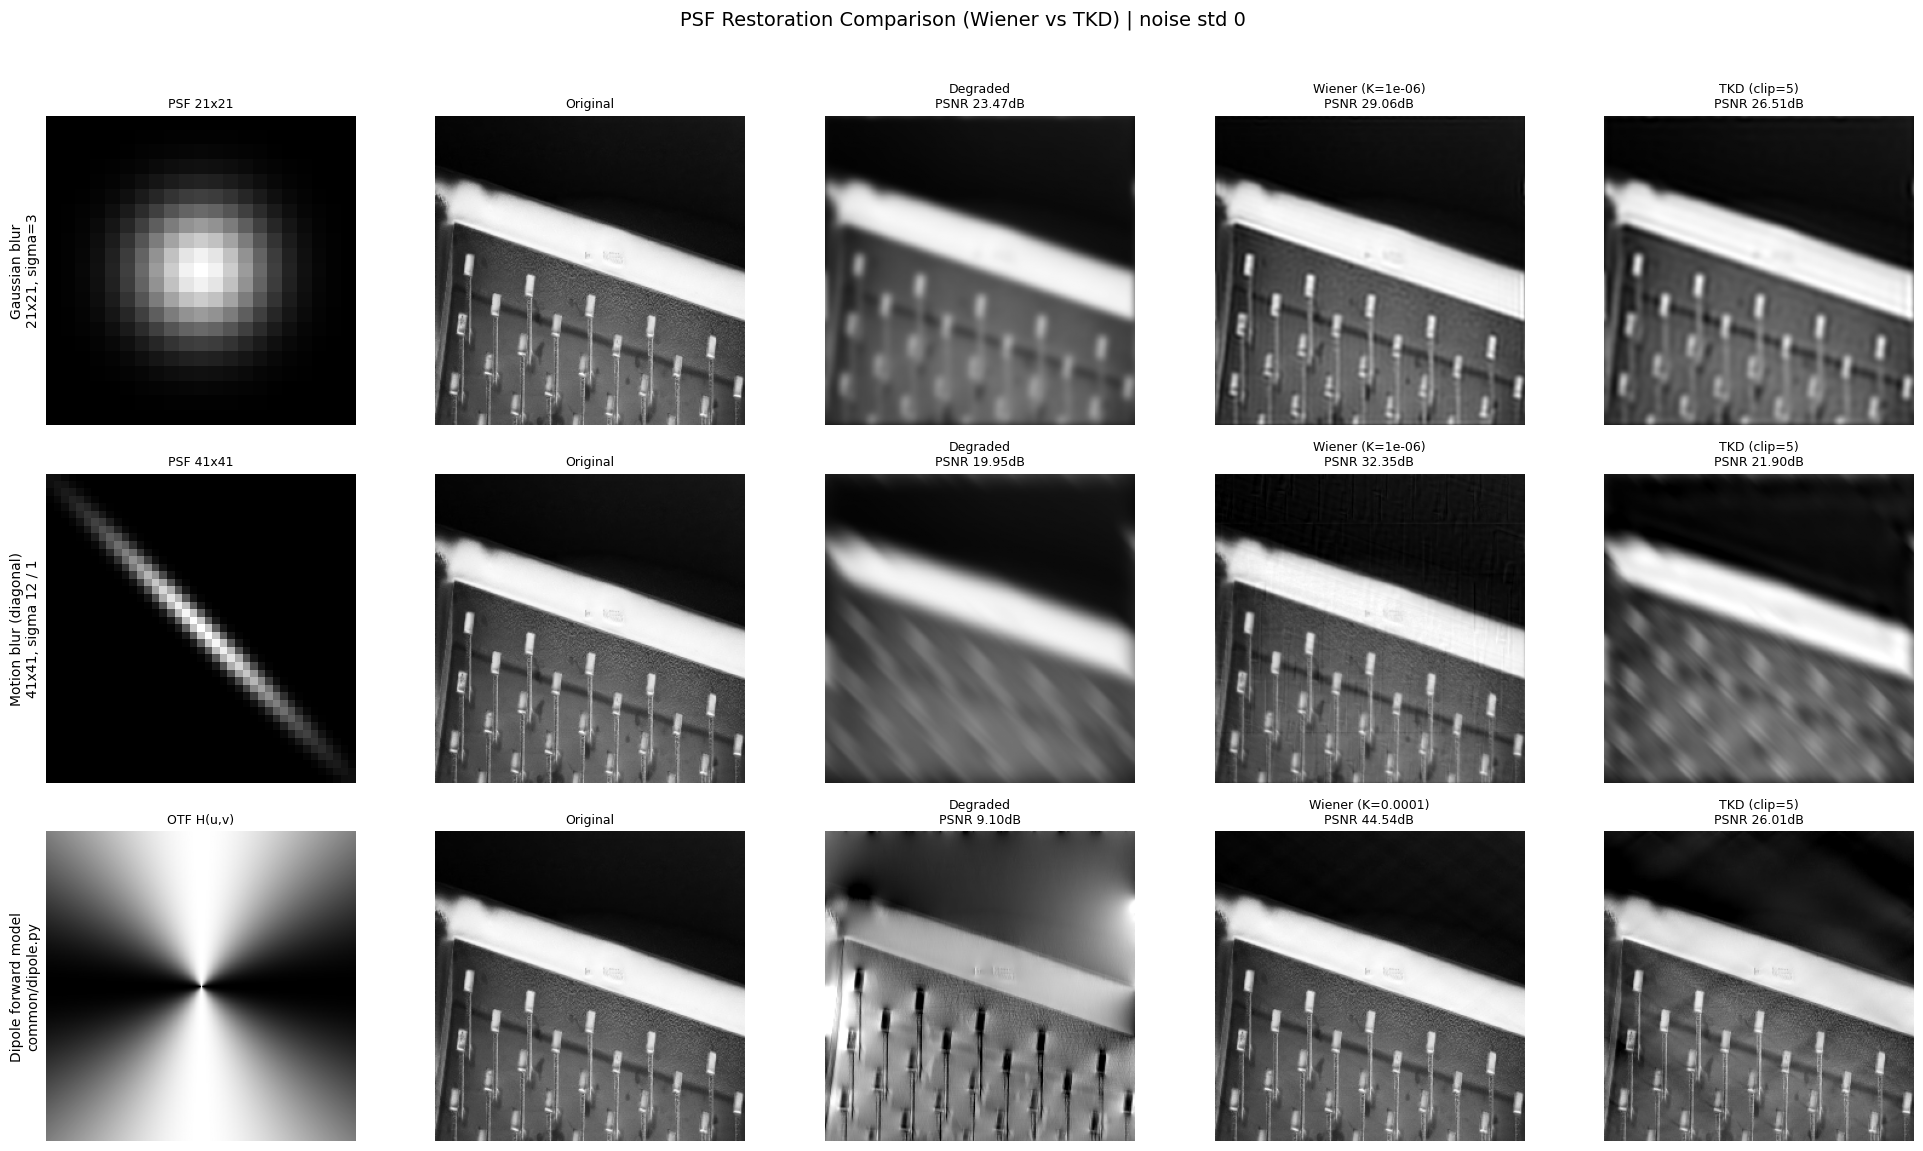

In [7]:
target_sample = bird if isinstance(globals().get("bird"), np.ndarray) else example
rng = np.random.default_rng(0)
rows: list[dict] = []

# 0열(PSF)은 정사각형이라 그냥 두면 다른 패널보다 세로로 커진다.
# 패널 수를 4개에서 5개로 늘리고 width_ratios를 조정합니다.
_aspect = target_sample.shape[0] / target_sample.shape[1]
fig, axes = plt.subplots(
    len(PSF_SPECS),
    5,
    figsize=(20, 3.9 * len(PSF_SPECS)),
    gridspec_kw={"width_ratios": [_aspect, 1, 1, 1, 1]},
)
axes = np.asarray(axes).reshape(len(PSF_SPECS), 5)

# TKD를 위한 clip 값 설정
TKD_CLIP_VAL = 5.0

for r, spec in enumerate(PSF_SPECS):
    otf = spec["otf"]

    # 1) blur (+ 선택적 노이즈)
    measure = apply_otf(target_sample, otf)
    if DEMO_NOISE_STD > 0:
        measure = measure + rng.normal(0.0, DEMO_NOISE_STD, measure.shape)

    # 2) Wiener 복원
    restored_wiener = np.clip(wiener_filter(measure, otf, K=spec["K"]), 0.0, 1.0)

    # 3) TKD 복원 (복소 OTF 는 크기만 자르고 위상은 보존한다)
    restored_tkd = np.clip(tkd_filter(measure, otf, clip=TKD_CLIP_VAL), 0.0, 1.0)

    psnr_deg, ssim_deg = psnr_ssim(measure, target_sample)
    psnr_wie, ssim_wie = psnr_ssim(restored_wiener, target_sample)
    psnr_tkd, ssim_tkd = psnr_ssim(restored_tkd, target_sample)

    rows.append({
        "psf": spec["key"],
        "psnr_degraded": psnr_deg,
        "psnr_wiener": psnr_wie,
        "psnr_tkd": psnr_tkd,
    })

    if spec["signed"]:
        deg_lo, deg_hi = float(np.percentile(measure, 1)), float(np.percentile(measure, 99))
    else:
        deg_lo, deg_hi = 0.0, 1.0

    if spec["psf"] is None:
        kernel_img = np.fft.fftshift(np.real(otf))
        kernel_title = "OTF H(u,v)"
        kernel_kw = {"cmap": "gray", "vmin": float(kernel_img.min()), "vmax": float(kernel_img.max())}
    else:
        kernel_img = spec["psf"]
        kernel_title = f"PSF {spec['psf'].shape[0]}x{spec['psf'].shape[1]}"
        kernel_kw = {"cmap": "gray"}

    panels = [
        (kernel_img, kernel_title, kernel_kw),
        (target_sample, "Original", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
        (measure, f"Degraded\nPSNR {psnr_deg:.2f}dB", {"cmap": "gray", "vmin": deg_lo, "vmax": deg_hi}),
        (restored_wiener, f"Wiener (K={spec['K']:g})\nPSNR {psnr_wie:.2f}dB", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
        (restored_tkd, f"TKD (clip={TKD_CLIP_VAL:g})\nPSNR {psnr_tkd:.2f}dB", {"cmap": "gray", "vmin": 0.0, "vmax": 1.0}),
    ]

    for c, (img, title, kw) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(img, **kw)
        ax.set_title(title, fontsize=9)
        if c == 0:
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values(): spine.set_visible(False)
            ax.set_ylabel(spec["label"], fontsize=10)
        else:
            ax.axis("off")

fig.suptitle(f"PSF Restoration Comparison (Wiener vs TKD) | noise std {DEMO_NOISE_STD:g}", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 2. Config

iter1 대비 바뀐 항목만 정리한다.

| 항목 | iter1 | iter2 | 이유 |
|---|---|---|---|
| `optimizer` | adam | **adamw** | weight decay 로 과적합 억제 |
| lr 스케줄 | `1e-4 * 0.88^epoch` | **cosine + warmup** (`2e-4 → 1e-6`) | iter1 은 성능이 오르는 중에 lr 이 죽었다 |
| `loss_model` | l2 | **charbonnier + data consistency** | 이상치 강건성 + 측정 일치성 |
| `chans` | 16 | **24** | 입력이 6채널이고 잔차만 배우므로 과대할 필요 없다 |
| `train_batch` | 64 | **24** | 256x256 6채널 + AMP 기준 T4 여유 |
| 증강 | flip 2종 | **dihedral 8종 + 노이즈 σ 랜덤** | measure 를 label 에서 즉석 생성하므로 rot90 도 유효 |
| validation | `*.npy` (L1+L8) | **`L1_*.npy`** | test 는 전부 L1 |
| AMP | 없음 | **있음** | T4 기준 약 2배 |


In [8]:
RUN_DIR = ROOT / "logs_deconvolution_iter2"


@dataclass
class GeneralConfig:
    # Dataset
    train_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "train")])
    valid_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "val")])
    test_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "test_label")])
    data_type: str = "*.npy"
    valid_data_type: str = "L1_*.npy"  # test_label 은 전부 L1 이므로 분포를 맞춘다
    test_measure_dir: str | None = None
    train_max_images: int | None = None  # 빠른 실험용 (None = 전체)

    # Logging
    log_lv: str = "INFO"
    run_dir: Path = RUN_DIR
    init_time: float = 0.0

    # Model / physics
    model_type: Literal["physics_unet"] = "physics_unet"
    base_mode: Literal["gcv_wiener", "gcv_grad", "fixed_wiener"] = "gcv_wiener"
    base_fixed_k: float = 1e-4  # base_mode="fixed_wiener" 일 때만 사용

    # Optimizer
    optimizer: Literal["adam", "adamw"] = "adamw"
    lr: float = 2e-4
    min_lr: float = 1e-6
    weight_decay: float = 1e-4
    warmup_epoch: int = 1

    # Loss
    charbonnier_eps: float = 1e-3
    loss_dc_weight: float = 0.1  # data consistency: |dipole(output) - measure|

    # Train params
    train_batch: int = 24
    valid_batch: int = 4
    train_epoch: int = 25
    logging_density: int = 4
    valid_interval: int = 1
    valid_tol: int = 0
    num_workers: int = 2
    parallel: bool = False
    amp: bool = True
    device: torch.device | None = None
    grad_clip: float = 1.0

    # Augmentation (measure 를 즉석 생성할 때만 적용된다)
    aug_dihedral: bool = True
    train_noise_zero_prob: float = 0.25  # 이 확률로는 노이즈 없이 학습
    train_noise_sigma_min: float = 3e-5
    train_noise_sigma_max: float = 3e-3

    # Eval
    use_tta: bool = True  # flip 4종 self-ensemble

    tag: str = "iter2"


@dataclass
class NetworkConfig:
    in_chans: int = 6  # physics 채널 수 (아래 PHYSICS_CHANNELS 와 일치해야 한다)
    out_chans: int = 1
    chans: int = 24
    num_pool_layers: int = 4


config = GeneralConfig()
networkconfig = NetworkConfig()


def resolve_measure_dir(path: Path) -> str | None:
    """measure 디렉토리를 찾는다. npy 가 한 단계 더 깊은 경우(test_x/test_x/*.npy)도 처리한다."""
    if not path.exists():
        return None
    if any(path.glob("*.npy")):
        return str(path)
    for sub in sorted(p for p in path.iterdir() if p.is_dir()):
        if any(sub.glob("*.npy")):
            return str(sub)
    return None


config.test_measure_dir = resolve_measure_dir(DATA_ROOT / "test_deconv_only")
if config.test_measure_dir is None:
    print(f"[warn] {DATA_ROOT / 'test_deconv_only'} 에 npy 가 없다 -> test 도 ForwardSimulator 로 즉석 생성한다")

for k, v in asdict(config).items():
    print(f"{k}: {v}")

[warn] /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_deconv_only 에 npy 가 없다 -> test 도 ForwardSimulator 로 즉석 생성한다
train_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
valid_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
test_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
data_type: *.npy
valid_data_type: L1_*.npy
test_measure_dir: None
train_max_images: None
log_lv: INFO
run_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2
init_time: 0.0
model_type: physics_unet
base_mode: gcv_wiener
base_fixed_k: 0.0001
optimizer: adamw
lr: 0.0002
min_lr: 1e-06
weight_decay: 0.0001
warmup_epoch: 1
charbonnier_eps: 0.001
loss_dc_weight: 0.1
train_batch: 24
valid_batch: 4
train_epoch: 25
logging_density: 4
valid_interval: 1
valid_tol: 0
num_workers: 2
parallel: False
amp: True
device: None
grad_clip: 1.0
aug_dihedral: True
train_noise_zero_prob: 0.25
train_nois

## 3. utils


In [9]:
def timestamp() -> str:
    return datetime.fromtimestamp(time.time()).strftime("%Y%m%d-%H%M%S")


def separator(cols: int = 100) -> str:
    return "#" * cols


def seconds_to_dhms(seconds: float) -> str:
    s = seconds % 60
    m = (seconds // 60) % 60
    h = seconds // (60 * 60) % 1000
    return f"{int(h):02}h {int(m):02}m {int(s):02}s"


def call_next_id(run_dir: Path) -> int:
    run_ids = []
    os.makedirs(run_dir, exist_ok=True)
    for entry in os.listdir(run_dir):
        if (run_dir / entry).is_dir():
            try:
                run_ids.append(int(entry.split("_")[0]))
            except ValueError:
                continue
    return max(run_ids, default=-1) + 1


def validate_tensors(tensors: list[Tensor]) -> None:
    for i, t in enumerate(tensors):
        if not isinstance(t, Tensor):
            raise TypeError(f"Tensor at index {i} is not a torch.Tensor, got {type(t)} instead.")


def validate_tensor_dimensions(tensors: list[Tensor], expected_dim: int) -> None:
    for i, t in enumerate(tensors):
        if t.dim() != expected_dim:
            raise ValueError(f"Tensor at index {i} has {t.dim()} dimensions, expected {expected_dim} dimensions.")

## 4. logger


In [10]:
import inspect
import sys
import traceback
from functools import wraps

from loguru import logger as logurulogger

LOGURU_LEVEL = ["TRACE", "DEBUG", "INFO", "SUCCESS", "WARNING", "ERROR", "CRITICAL"]
FORMAT = "{time:YYYY-MM-DD HH:mm:ss} <level>[{level}]</level> {message}"
LOGURU_LV_LOWER = [x.lower() for x in LOGURU_LEVEL]


class SingletonMeta(type):
    _instances: dict[Any, Any] = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            instance = super().__call__(*args, **kwargs)
            cls._instances[cls] = instance
        return cls._instances[cls]


class CustomLogger(metaclass=SingletonMeta):
    def __getattr__(self, name: str) -> Any:
        if name not in LOGURU_LV_LOWER:
            return getattr(logurulogger, name)

        def custom_handler(message: str | Any) -> None:
            if name == "error":
                caller_name = inspect.stack()[1].function
                getattr(logurulogger, name)(f"Error in func {caller_name}")

            if isinstance(message, str):
                for _item in message.split("\n"):
                    getattr(logurulogger, name)(_item)
            else:
                getattr(logurulogger, name)(message)

        return custom_handler

    def trace(self, message: Any) -> None:
        self.__getattr__("trace")(message)

    def debug(self, message: Any) -> None:
        self.__getattr__("debug")(message)

    def info(self, message: Any) -> None:
        self.__getattr__("info")(message)

    def success(self, message: Any) -> None:
        self.__getattr__("success")(message)

    def warning(self, message: Any) -> None:
        self.__getattr__("warning")(message)

    def error(self, message: Any) -> None:
        self.__getattr__("error")(message)

    def critical(self, message: Any) -> None:
        self.__getattr__("critical")(message)


def logger_add_handler(
    _logger: CustomLogger,
    file: str | Path | None = None,
    level: str | None = None,
) -> None:
    _logger.remove()
    if level is None:
        level = "TRACE"
    _logger.add(sys.stdout, colorize=True, format=FORMAT, level=level)
    if file is None:
        return
    os.makedirs(Path(file).parent, exist_ok=True)
    _logger.add(file, colorize=True, format=FORMAT, level=level)


logger = CustomLogger()
logger_add_handler(logger)


def error_wrap(func: Callable) -> Callable:
    """common/wrapper.py. 예외를 로그로 남기고 None 을 돌려준다 (notebook 이므로 sync 만)."""

    @wraps(func)
    def sync_wrapper(*args: Any, **kwargs: Any) -> Any:
        try:
            return func(*args, **kwargs)
        except Exception as err:
            logger.error(f"Error in {func.__name__}: {err}\n{traceback.format_exc()}")
            return None

    return sync_wrapper

## 5. MetricController


In [11]:
class MetricController:
    def __init__(self) -> None:
        self.state_dict: dict[str, list[float]] = {}

    def reset(self) -> None:
        self.state_dict = {}

    def add(
        self,
        key: str,
        value: torch.Tensor,
    ) -> None:
        if not isinstance(key, str):
            raise TypeError(f"{key} is not a string")

        if not isinstance(value, torch.Tensor):
            raise TypeError(f"{value} is not torch.Tensor")

        if key not in self.state_dict:
            self.state_dict[key] = []

        if value.dim() == 4 and value.shape[1:] == (1, 1, 1):
            value = value.view(-1)
        elif value.dim() == 1:
            pass
        else:
            raise ValueError(f"Expected value to have shape (b, 1, 1, 1) or (b,), but got {value.shape}")

        value = value.cpu().detach().numpy()
        self.state_dict[key].extend(value.flatten())

    def mean(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.mean(self.state_dict[key])

    def std(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.std(self.state_dict[key], ddof=1)

## 6. Analytic dipole inversion (학습 불필요)

forward model 이 주어졌으므로 역필터는 모두 k-space 대각 연산이다.

$$\hat X(\mathbf k) = \frac{H(\mathbf k)}{H(\mathbf k)^2 + R(\mathbf k)} Y(\mathbf k)$$

| 방법 | $R(\mathbf k)$ |
|---|---|
| inverse filter | 0 |
| Wiener / Tikhonov | $K$ (상수) — 두 방법은 **대수적으로 동일**하다 |
| gradient 가중 Tikhonov | $\lambda \lvert \mathbf k \rvert^2$ (고주파를 더 강하게 억제) |
| TKD | $1/H$ 의 **크기**를 clip (위상 보존) |

### 정규화 세기를 label 없이 고르는 방법: GCV

$$\mathrm{GCV}(R) = \frac{N \lVert H\hat x - y \rVert^2}{\big(\mathrm{tr}(I - A)\big)^2}, \qquad A(\mathbf k) = \frac{H^2}{H^2 + R}$$

전부 k-space 대각이라 닫힌 형태로 계산된다. **label 이 필요 없으므로 실제 챌린지 test measure 에도 그대로 쓸 수 있다.**
고정 K 는 노이즈 세기가 조금만 달라져도 무너진다 (σ=1e-4 일 때 K=0 → 28.9 dB, K=3e-6 → 47.1 dB).


In [12]:
@lru_cache(maxsize=8)
def dipole_freq_grid(
    matrix_size: tuple[int, int],
    voxel_size: tuple[float, float] = (1.0, 1.0),
) -> torch.Tensor:
    """|k|^2 을 max=1 로 정규화한 격자. dipole_kernel 과 같은 fftshift 배치."""
    y = np.arange(-matrix_size[1] / 2, matrix_size[1] / 2, 1)
    x = np.arange(-matrix_size[0] / 2, matrix_size[0] / 2, 1)
    Y, X = np.meshgrid(y, x)
    X = X / (matrix_size[0] * voxel_size[0])
    Y = Y / (matrix_size[1] * voxel_size[1])
    k2 = X**2 + Y**2
    k2 = k2 / k2.max()
    return torch.tensor(np.fft.fftshift(k2), dtype=torch.float32)


def kernel_like(
    img: Tensor,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """img 와 같은 크기/디바이스의 dipole OTF."""
    return dipole_kernel(
        matrix_size=tuple(img.shape[-2:]),
        voxel_size=(1.0, 1.0),
        B0_dir=B0_dir,
    ).to(img.device)


def dipole_forward(
    img: Tensor,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """measure = ifft(fft(img) * H)."""
    H = kernel_like(img, B0_dir)
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) * H, dim=(-2, -1)).real


def regularized_inverse(
    img: Tensor,
    reg: Tensor | float,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """x = H / (H^2 + reg) * y. reg 는 스칼라 / (B,1,1,1) / (B,1,H,W) 모두 된다."""
    H = kernel_like(img, B0_dir)
    filt = H / (H**2 + reg)
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) * filt, dim=(-2, -1)).real


def wiener_deconv(
    img: Tensor,
    K: Tensor | float = 1e-4,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """Wiener = (1/H) * H^2/(H^2+K) = H/(H^2+K) (실수 kernel). Tikhonov(lambda=K) 와 동일하다."""
    return regularized_inverse(img, K, B0_dir)


def tikhonov_grad_deconv(
    img: Tensor,
    lam: Tensor | float = 1e-4,
    power: float = 1.0,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """gradient 가중 Tikhonov: argmin ||Hx-y||^2 + lam * || |k|^power x ||^2."""
    k2 = dipole_freq_grid(tuple(img.shape[-2:])).to(img.device)
    return regularized_inverse(img, lam * k2**power, B0_dir)


def tkd_deconv(
    img: Tensor,
    clip: float = 5.0,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """TKD: |1/H| 를 clip 으로 제한한다 (실수 kernel 이므로 부호만 유지)."""
    H = kernel_like(img, B0_dir)
    return torch.fft.ifftn(torch.fft.fftn(img, dim=(-2, -1)) * torch.clip(1 / H, -clip, clip), dim=(-2, -1)).real


GCV_GRID: tuple[float, ...] = (
    1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5, 3e-6, 1e-6, 3e-7, 1e-7, 3e-8, 1e-8, 3e-9, 1e-9,
)


def gcv_score(
    img: Tensor,
    reg: Tensor | float,
    B0_dir: tuple[float, float] = (0.0, 1.0),
) -> Tensor:
    """GCV(reg). label 이 필요 없다. 반환 shape (B,1,1,1)."""
    H = kernel_like(img, B0_dir)
    h2 = H**2
    y2 = torch.fft.fftn(img, dim=(-2, -1)).abs() ** 2
    r = torch.as_tensor(reg, device=img.device, dtype=h2.dtype) * torch.ones_like(h2)
    n = float(h2.numel())
    resid = (r**2 * y2 / (h2 + r) ** 2).sum(dim=(-2, -1), keepdim=True) / n
    trace = (r / (h2 + r)).sum(dim=(-2, -1), keepdim=True)
    return n * resid / trace**2


def gcv_select(
    img: Tensor,
    grid: tuple[float, ...] = GCV_GRID,
    mode: Literal["wiener", "grad"] = "wiener",
) -> Tensor:
    """이미지별로 GCV 를 최소화하는 정규화 세기를 고른다. 반환 shape (B,1,1,1)."""
    k2 = dipole_freq_grid(tuple(img.shape[-2:])).to(img.device) if mode == "grad" else None
    scores = torch.stack([gcv_score(img, float(g) if k2 is None else float(g) * k2) for g in grid], dim=0)
    idx = scores.argmin(dim=0)  # (B,1,1,1)
    lut = torch.tensor(grid, device=img.device, dtype=img.dtype)
    return lut[idx]


def analytic_deconv(
    img: Tensor,
    mode: str | None = None,
) -> tuple[Tensor, Tensor]:
    """label 없이 정규화 세기를 정하고 역필터를 적용한다. (복원, 선택된 세기) 반환."""
    mode = mode if mode is not None else config.base_mode
    if mode == "gcv_wiener":
        k = gcv_select(img, mode="wiener")
        return wiener_deconv(img, k), k
    if mode == "gcv_grad":
        lam = gcv_select(img, mode="grad")
        return tikhonov_grad_deconv(img, lam), lam
    if mode == "fixed_wiener":
        k = torch.full((img.shape[0], 1, 1, 1), config.base_fixed_k, device=img.device)
        return wiener_deconv(img, k), k
    raise KeyError(f"unknown base_mode: {mode}")


def _analytic_self_check() -> None:
    torch.manual_seed(0)
    x = torch.rand(2, 1, 64, 64)
    y = dipole_forward(x)

    # 1) flip 등변성: dipole(flip x) == flip(dipole x) -> flip TTA 가 유효하다
    for dims in ([-1], [-2], [-2, -1]):
        err = (dipole_forward(torch.flip(x, dims=dims)) - torch.flip(y, dims=dims)).abs().max().item()
        assert err < 1e-5, f"flip{dims} 등변성 실패: {err:.2e}"
    # 2) rot90 은 B0 방향이 바뀌므로 등변이 아니다 (TTA 에 쓰면 안 된다)
    rot_err = (dipole_forward(torch.rot90(x, 1, dims=(-2, -1))) - torch.rot90(y, 1, dims=(-2, -1))).abs().max().item()
    assert rot_err > 1e-3, "rot90 이 등변으로 나온다 - kernel 설정 확인 필요"
    # 3) Wiener == Tikhonov (실수 kernel)
    assert torch.allclose(wiener_deconv(y, 1e-3), regularized_inverse(y, 1e-3), atol=1e-6)
    # 4) GCV 출력 shape
    k = gcv_select(y)
    assert k.shape == (2, 1, 1, 1), k.shape

    print(f"analytic self-check ok | flip 등변 오차 < 1e-5, rot90 오차 {rot_err:.3f} (TTA 는 flip 만)")
    print(f"GCV 선택 K: {[f'{v:.0e}' for v in k.flatten().tolist()]}")


_analytic_self_check()

analytic self-check ok | flip 등변 오차 < 1e-5, rot90 오차 0.673 (TTA 는 flip 만)
GCV 선택 K: ['1e-09', '1e-09']


### 6-1. GCV 검증 (label 없이 고른 K 가 oracle 에 얼마나 가까운가)

validation label 로 measure 를 직접 만들어 노이즈 세기별로 비교한다.
`oracle` 은 label 을 보고 PSNR 이 최대인 K 를 고른 경우(실전에서는 불가능), `GCV` 는 label 없이 고른 경우다.


In [13]:
_val_files = sorted(glob.glob(str(Path(config.valid_dataset[0]) / config.valid_data_type)))
if not _val_files:
    _val_files = sorted(glob.glob(str(Path(config.valid_dataset[0]) / config.data_type)))
_n_chk = min(8, len(_val_files))
_lab = torch.stack([torch.from_numpy(np.load(f)).float()[None] for f in _val_files[:_n_chk]])
print(f"GCV 검증에 사용한 validation 영상 {_n_chk}장")

torch.manual_seed(0)
print()
print(f"{'sigma':>8} | {'oracle K':>9} {'oracle PSNR':>12} | {'GCV K':>9} {'GCV PSNR':>10} | {'K=1e-4 (iter1)':>15}")
print("-" * 78)
for _sigma in [0.0, 1e-4, 3e-4, 1e-3, 3e-3]:
    _meas = dipole_forward(_lab) + torch.randn_like(_lab) * _sigma
    _scores = {}
    for _k in GCV_GRID:
        _scores[_k] = calculate_psnr(wiener_deconv(_meas, _k).clamp(0, 1), _lab).mean().item()
    _ok = max(_scores, key=_scores.get)
    _gk = gcv_select(_meas).flatten()
    _gp = calculate_psnr(wiener_deconv(_meas, gcv_select(_meas)).clamp(0, 1), _lab).mean().item()
    print(
        f"{_sigma:>8.0e} | {_ok:>9.0e} {_scores[_ok]:>12.3f} | "
        f"{_gk.median().item():>9.0e} {_gp:>10.3f} | {_scores[1e-4]:>15.3f}"
    )
print()
print("고정 K=1e-4 는 노이즈가 없을 때 크게 손해를 보고, K=0 에 가깝게 두면 노이즈가 조금만 있어도 붕괴한다.")

GCV 검증에 사용한 validation 영상 8장

   sigma |  oracle K  oracle PSNR |     GCV K   GCV PSNR |  K=1e-4 (iter1)
------------------------------------------------------------------------------
   0e+00 |     1e-09       81.434 |     1e-09     81.434 |          43.692
   1e-04 |     3e-06       48.067 |     1e-06     47.357 |          43.428
   3e-04 |     3e-05       42.812 |     1e-05     41.929 |          42.022
   1e-03 |     3e-04       37.130 |     3e-05     35.336 |          36.622
   3e-03 |     1e-03       31.703 |     3e-04     29.708 |          28.260

고정 K=1e-4 는 노이즈가 없을 때 크게 손해를 보고, K=0 에 가깝게 두면 노이즈가 조금만 있어도 붕괴한다.


## 7. Physics-informed 입력

CNN 에 raw measure 만 주면 전역 역연산까지 학습해야 한다 (iter1 이 실패한 지점).
대신 **역필터 결과를 채널로 넣고, 네트워크는 그 잔차만 예측**하게 한다.

| ch | 내용 | 역할 |
|---|---|---|
| 0 | `measure * MEASURE_SCALE` | 원 측정값 (스케일만 맞춤) |
| 1 | `base` = GCV Wiener | 주 추정치이자 residual 의 기준 |
| 2 | 과정규화 (`K*10`) | 부드러운(노이즈 적은) 버전 |
| 3 | 과소정규화 (`K*0.1`) | 날카로운(노이즈 많은) 버전 |
| 4 | gradient Tikhonov (`K*3`) | 고주파 억제 버전 |
| 5 | `log10(K)` 상수맵 | **노이즈 세기 조건 입력** (FFDNet 방식). 무노이즈/유노이즈 regime 을 구분한다 |


In [14]:
MEASURE_SCALE: float = 3.0  # measure 진폭(~0.3)을 label 스케일(~1)에 맞춘다
PREP_SOFT_MULT: float = 10.0
PREP_SHARP_MULT: float = 0.1
PREP_GRAD_MULT: float = 3.0
PREP_CLAMP: tuple[float, float] = (-1.0, 2.0)
PHYSICS_CHANNELS: int = 6


def build_physics_input(measure: Tensor) -> tuple[Tensor, Tensor, Tensor]:
    """measure -> (network 입력 (B,6,H,W), base 추정 (B,1,H,W), 선택된 정규화 세기 (B,1,1,1))."""
    base, reg = analytic_deconv(measure)
    soft = wiener_deconv(measure, reg * PREP_SOFT_MULT)
    sharp = wiener_deconv(measure, reg * PREP_SHARP_MULT)
    grad = tikhonov_grad_deconv(measure, reg * PREP_GRAD_MULT)
    log_reg = ((torch.log10(reg) + 8.0) / 8.0).expand_as(measure)

    lo, hi = PREP_CLAMP
    x = torch.cat(
        [
            measure * MEASURE_SCALE,
            base.clamp(lo, hi),
            soft.clamp(lo, hi),
            sharp.clamp(lo, hi),
            grad.clamp(lo, hi),
            log_reg,
        ],
        dim=1,
    )
    return x, base, reg


def _physics_self_check() -> None:
    meas = dipole_forward(_lab[:4])
    x, base, reg = build_physics_input(meas)
    assert x.shape[1] == PHYSICS_CHANNELS == networkconfig.in_chans, (x.shape, networkconfig.in_chans)
    names = ["measure*scale", "base (GCV Wiener)", f"soft (K*{PREP_SOFT_MULT:g})", f"sharp (K*{PREP_SHARP_MULT:g})", f"gradTikh (K*{PREP_GRAD_MULT:g})", "log10(K) map"]
    print(f"input shape {tuple(x.shape)} | 선택된 K {[f'{v:.0e}' for v in reg.flatten().tolist()]}")
    print()
    print(f"{'channel':<26}{'PSNR vs label':>14}{'min':>9}{'max':>9}")
    print("-" * 58)
    for c in range(PHYSICS_CHANNELS):
        ch = x[:, c : c + 1]
        p = calculate_psnr(ch.clamp(0, 1), _lab[:4]).mean().item() if c != 5 else float("nan")
        print(f"{names[c]:<26}{p:>14.3f}{ch.min().item():>9.3f}{ch.max().item():>9.3f}")
    print()
    print(f"measure 자체 PSNR : {calculate_psnr(meas, _lab[:4]).mean().item():.3f} dB")
    print(f"base  PSNR        : {calculate_psnr(base.clamp(0, 1), _lab[:4]).mean().item():.3f} dB  <- 학습 시작점")


_physics_self_check()

input shape (4, 6, 256, 256) | 선택된 K ['1e-09', '1e-09', '1e-09', '1e-09']

channel                    PSNR vs label      min      max
----------------------------------------------------------
measure*scale                     14.531   -1.285    1.136
base (GCV Wiener)                 80.262    0.027    0.997
soft (K*10)                       72.239    0.027    0.997
sharp (K*0.1)                     92.698    0.027    0.997
gradTikh (K*3)                    79.410    0.027    0.997
log10(K) map                         nan   -0.125   -0.125

measure 자체 PSNR : 8.330 dB
base  PSNR        : 80.262 dB  <- 학습 시작점


## 8. U-Net backbone

iter1 과 동일한 U-Net (ConvBlock + GroupNorm + SiLU). 입력 채널 수만 physics 채널로 바뀐다.


In [15]:
def create_down_sample_layers(
    in_chans: int,
    chans: int,
    num_pool_layers: int,
) -> nn.ModuleList:
    layers = nn.ModuleList([ConvBlock(in_chans, chans)])
    ch = chans
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch, ch * 2))
        ch *= 2
    return layers


def create_up_sample_layers(
    chans: int,
    num_pool_layers: int,
) -> nn.ModuleList:
    layers = nn.ModuleList()
    ch = chans * (2 ** (num_pool_layers - 1))
    for _ in range(num_pool_layers - 1):
        layers.append(ConvBlock(ch * 2, ch // 2))
        ch //= 2
    layers.append(ConvBlock(ch * 2, ch))
    return layers


class ConvBlock(nn.Module):
    def __init__(
        self,
        in_chans: int,
        out_chans: int,
    ) -> None:
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_chans, out_chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, out_chans),
            nn.SiLU(inplace=True),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        return self.layers(x)


class Unet(nn.Module):
    def __init__(
        self,
        in_chans: int = 1,
        out_chans: int = 1,
        chans: int = 32,
        num_pool_layers: int = 4,
    ) -> None:
        super().__init__()

        self.in_chans = in_chans
        self.out_chans = out_chans
        self.num_pool_layers = num_pool_layers

        # Down-sampling layers
        self.down_sample_layers = create_down_sample_layers(in_chans, chans, num_pool_layers)

        # Bottleneck layer
        self.bottleneck_conv = ConvBlock(chans * (2 ** (num_pool_layers - 1)), chans * (2 ** (num_pool_layers - 1)))

        # Up-sampling layers
        self.up_sample_layers = create_up_sample_layers(chans, num_pool_layers)

        # Final convolution layers
        self.final_conv = nn.Sequential(
            nn.Conv2d(chans, chans, kernel_size=3, padding=1),
            nn.GroupNorm(4, chans),
            nn.SiLU(inplace=True),
            nn.Conv2d(chans, out_chans, kernel_size=1, padding=0),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        stack = []
        output = x
        # Down-sampling
        for layer in self.down_sample_layers:
            output = layer(output)
            stack.append(output)
            output = functional.max_pool2d(output, kernel_size=2)

        # Bottleneck
        output = self.bottleneck_conv(output)

        # Up-sampling
        for layer in self.up_sample_layers:
            downsampled_output = stack.pop()
            layer_size = downsampled_output.shape[-2:]
            output = functional.interpolate(output, size=layer_size, mode="bilinear", align_corners=False)
            output = torch.cat([output, downsampled_output], dim=1)
            output = layer(output)

        output = self.final_conv(output)
        return output

## 8. Residual U-Net

`output = base + UNet(physics_input)` 이고 **마지막 conv 를 0 으로 초기화**한다.
따라서 학습 시작 시 출력이 analytic 복원(base)과 정확히 같고, 학습은 그보다 좋아지는 방향으로만 진행된다.
(gate 파라미터를 따로 두면 zero-init 과 곱해져 gradient 가 0 이 되어 학습이 죽으므로 쓰지 않는다.)


In [16]:
class PhysicsResidualUnet(nn.Module):
    def __init__(
        self,
        in_chans: int = PHYSICS_CHANNELS,
        out_chans: int = 1,
        chans: int = 24,
        num_pool_layers: int = 4,
    ) -> None:
        super().__init__()
        self.unet = Unet(
            in_chans=in_chans,
            out_chans=out_chans,
            chans=chans,
            num_pool_layers=num_pool_layers,
        )
        # 마지막 1x1 conv 를 0 으로 -> 초기 residual 이 정확히 0
        last = self.unet.final_conv[-1]
        nn.init.zeros_(last.weight)
        if last.bias is not None:
            nn.init.zeros_(last.bias)

    def forward(
        self,
        x: Tensor,
        base: Tensor,
    ) -> Tensor:
        return base + self.unet(x)


def get_network(
    device: torch.device | None,
    networkconfig: NetworkConfig,
) -> nn.Module:
    if device is None:
        raise TypeError("device is not to be None")
    return PhysicsResidualUnet(
        in_chans=networkconfig.in_chans,
        out_chans=networkconfig.out_chans,
        chans=networkconfig.chans,
        num_pool_layers=networkconfig.num_pool_layers,
    )


_net = PhysicsResidualUnet(chans=networkconfig.chans)
_meas = dipole_forward(_lab[:2])
_x, _base, _ = build_physics_input(_meas)
with torch.no_grad():
    _out = _net(_x, _base)
print(f"params: {sum(p.numel() for p in _net.parameters()) / 1e6:.3f} M")
print(f"forward: {tuple(_x.shape)} + base -> {tuple(_out.shape)}")
print(f"초기 출력 == base ? max diff {(_out - _base).abs().max().item():.3e}")
print(f"초기 PSNR: {calculate_psnr(_out.clamp(0, 1), _lab[:2]).mean().item():.3f} dB "
      f"(base {calculate_psnr(_base.clamp(0, 1), _lab[:2]).mean().item():.3f} dB)")
del _net

params: 1.893 M
forward: (2, 6, 256, 256) + base -> (2, 1, 256, 256)
초기 출력 == base ? max diff 0.000e+00
초기 PSNR: 76.663 dB (base 76.663 dB)


## 9. ForwardSimulator (노이즈 σ 랜덤 증강)

`Day 1` 에 "noise characteristic is not given" 이라고 명시되어 있으므로 노이즈를 고정하지 않는다.
`train_noise_zero_prob` 확률로는 무노이즈, 나머지는 `[σ_min, σ_max]` 에서 **log-uniform** 으로 뽑는다.
base 의 정규화 세기는 GCV 가 측정값만 보고 자동으로 맞추므로, 네트워크는 σ 조건 채널(ch5)과 함께 두 regime 을 모두 학습한다.


In [17]:
class ForwardSimulator:
    def __init__(
        self,
        B0_dir: tuple[float, float] = (0.0, 1.0),
        voxel_size: tuple[float, float] = (1.0, 1.0),
        noise_type: str = "gaussian",
        noise_zero_prob: float = 1.0,
        noise_sigma_min: float = 3e-5,
        noise_sigma_max: float = 0.0,
    ) -> None:
        """g(x,y) = h(x,y) * f(x,y) + eta(x,y). sigma 는 샘플마다 log-uniform 으로 뽑는다."""
        self.B0_dir = B0_dir
        self.voxel_size = voxel_size
        self.noise_type = noise_type
        self.noise_zero_prob = noise_zero_prob
        self.noise_sigma_min = noise_sigma_min
        self.noise_sigma_max = noise_sigma_max

    def sample_sigma(self) -> float:
        if self.noise_sigma_max <= 0.0 or random.random() < self.noise_zero_prob:
            return 0.0
        lo, hi = math.log10(max(self.noise_sigma_min, 1e-12)), math.log10(self.noise_sigma_max)
        return float(10 ** random.uniform(lo, hi))

    def add_noise(
        self,
        img: Tensor,
        sigma: float,
    ) -> Tensor:
        if sigma <= 0.0:
            return img
        if self.noise_type == "gaussian":
            return img + torch.randn_like(img) * sigma
        if self.noise_type == "uniform":
            return img + (torch.rand_like(img) - 0.5) * 2 * (math.sqrt(3) * sigma)
        raise KeyError(f"unknown noise_type: {self.noise_type}")

    def __call__(
        self,
        img: Tensor,
        sigma: float | None = None,
    ) -> Tensor:
        if not isinstance(img, torch.Tensor):
            raise TypeError("Input must be a torch.Tensor")

        orig_dim = img.dim()
        if orig_dim == 2:
            x = img[None, None]
        elif orig_dim == 3:
            x = img[None]
        elif orig_dim == 4:
            x = img
        else:
            raise ValueError(f"Unsupported image dimension: {orig_dim}")

        out = dipole_forward(x, B0_dir=self.B0_dir)
        out = self.add_noise(out, self.sample_sigma() if sigma is None else sigma)

        if orig_dim == 2:
            return out[0, 0]
        if orig_dim == 3:
            return out[0]
        return out

## 10. DataWrapper / DataLoader

- **dihedral 8종 증강**: measure 를 label 에서 즉석 생성하므로 rot90 도 물리적으로 유효한 pair 가 된다
  (measure = dipole(rot90(label))). 미리 만들어 둔 measure 를 쓰는 경우에는 dipole kernel 이 rot90 에 불변이
  아니므로 **flip 만** 적용한다.
- Windows 경로에서도 basename 이 잘리도록 `Path(...).name` 을 쓴다 (iter1 버그 수정).


In [18]:
class DataKey(IntEnum):
    Label = 0
    Measure = 1
    Name = 2


@dataclass
class LoaderConfig:
    data_type: str
    batch: int
    num_workers: int
    shuffle: bool
    measure_path: str | None = None
    max_images: int | None = None
    augment: bool = False


class DataWrapper(Dataset):
    def __init__(
        self,
        file_path: list[str],
        data_type: str,
        augment: bool,
        measure_path: str | None = None,
        max_images: int | None = None,
    ) -> None:
        super().__init__()
        self.augment = augment
        self.measure_path = Path(measure_path) if measure_path is not None else None
        self.forward_simulator = ForwardSimulator(
            noise_zero_prob=config.train_noise_zero_prob if augment else 1.0,
            noise_sigma_min=config.train_noise_sigma_min,
            noise_sigma_max=config.train_noise_sigma_max if augment else 0.0,
        )

        total: list[str] = []
        for _p in file_path:
            total += glob.glob(f"{_p}/{data_type}")
        total = sorted(total)
        if max_images is not None:
            total = total[:max_images]
        self.file_list = total

    @staticmethod
    def _load(file_npy: str) -> Tensor:
        img = torch.from_numpy(np.load(file_npy)).type(torch.float)
        return img.unsqueeze(0) if img.dim() == 2 else img

    def _flip(
        self,
        label: Tensor,
        measure: Tensor | None,
    ) -> tuple[Tensor, Tensor | None]:
        """dipole kernel 은 flip 에 등변이므로 label/measure 를 함께 뒤집어도 된다."""
        for dim in (1, 2):
            if random.random() < 0.5:
                label = torch.flip(label, dims=[dim])
                measure = torch.flip(measure, dims=[dim]) if measure is not None else None
        return label, measure

    def _dihedral(self, label: Tensor) -> Tensor:
        """rot90 + flip (8종). measure 를 이후에 생성하는 경우에만 쓴다."""
        k = random.randint(0, 3)
        if k:
            label = torch.rot90(label, k, dims=(1, 2))
        if random.random() < 0.5:
            label = torch.flip(label, dims=[2])
        return label.contiguous()

    def __getitem__(self, idx: int):
        path = self.file_list[idx]
        _name = Path(path).name  # Windows 경로(\\) 대응
        label = self._load(path)

        if self.measure_path is None:
            if self.augment:
                label = self._dihedral(label) if config.aug_dihedral else self._flip(label, None)[0]
            measure = self.forward_simulator(label)
        else:
            measure_file = self.measure_path / _name
            if not measure_file.exists():
                raise FileNotFoundError(f"Matching measure file not found: {measure_file}")
            measure = self._load(str(measure_file))
            if self.augment:
                label, measure = self._flip(label, measure)

        return label, measure, _name

    def __len__(self) -> int:
        return len(self.file_list)


def get_data_wrapper_loader(
    file_path: list[str],
    loader_cfg: LoaderConfig,
) -> tuple[DataLoader, DataWrapper, int]:
    dataset = DataWrapper(
        file_path=file_path,
        data_type=loader_cfg.data_type,
        augment=loader_cfg.augment,
        measure_path=loader_cfg.measure_path,
        max_images=loader_cfg.max_images,
    )
    if len(dataset) == 0:
        raise FileNotFoundError(f"No data found in {file_path} with pattern {loader_cfg.data_type}")
    _ = dataset[0]

    loader = DataLoader(
        dataset,
        batch_size=loader_cfg.batch,
        num_workers=loader_cfg.num_workers,
        pin_memory=True,
        persistent_workers=loader_cfg.num_workers > 0,
        shuffle=loader_cfg.shuffle,
        drop_last=False,
    )
    return loader, dataset, len(dataset)

### 10-1. 데이터 확인

label / measure / base(GCV 역필터) 를 함께 본다. base 가 이미 label 에 가깝다는 것이 iter2 의 출발점이다.


train dataset length: 7268
label   : (4, 1, 256, 256)  range [0.001, 0.963]
measure : (4, 1, 256, 256)  range [-0.045, 0.465]
GCV K   : ['3e-04', '3e-07', '1e-09', '1e-05']


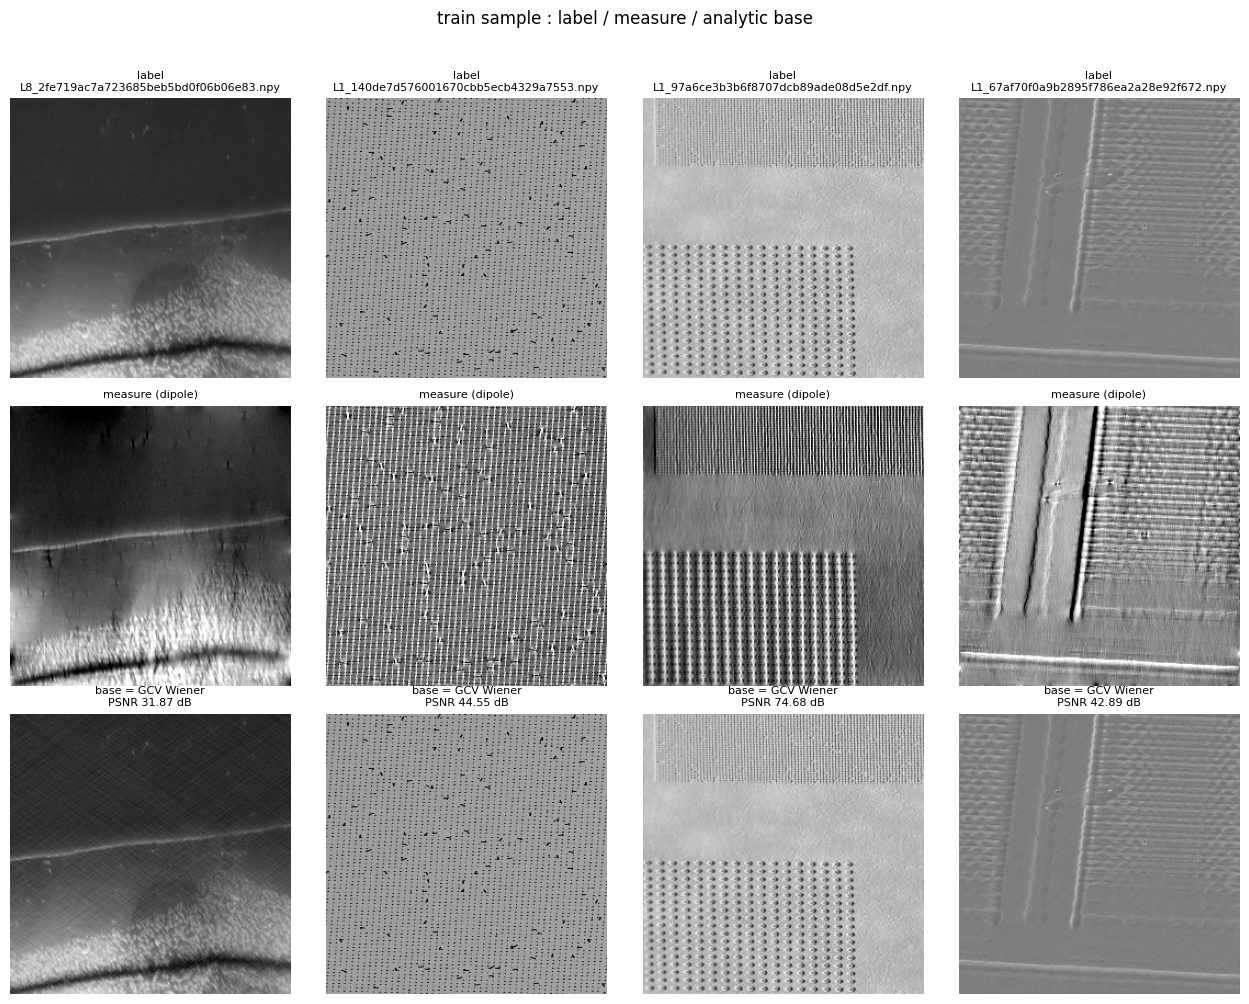

In [19]:
_loader, _, _len = get_data_wrapper_loader(
    file_path=config.train_dataset,
    loader_cfg=LoaderConfig(data_type=config.data_type, batch=4, num_workers=0, shuffle=True, augment=True),
)
print(f"train dataset length: {_len}")

_l, _m, _n = next(iter(_loader))
_b, _reg = analytic_deconv(_m)
print(f"label   : {tuple(_l.shape)}  range [{_l.min():.3f}, {_l.max():.3f}]")
print(f"measure : {tuple(_m.shape)}  range [{_m.min():.3f}, {_m.max():.3f}]")
print(f"GCV K   : {[f'{v:.0e}' for v in _reg.flatten().tolist()]}")

_nn = _l.shape[0]
fig, axes = plt.subplots(3, _nn, figsize=(3.2 * _nn, 10.2))
for i in range(_nn):
    axes[0, i].imshow(_l[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label\n{_n[i]}", fontsize=8)
    _mm = _m[i, 0].numpy()
    axes[1, i].imshow(_mm, cmap="gray", vmin=np.percentile(_mm, 1), vmax=np.percentile(_mm, 99))
    axes[1, i].set_title("measure (dipole)", fontsize=8)
    axes[2, i].imshow(_b[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[2, i].set_title(
        f"base = GCV Wiener\nPSNR {calculate_psnr(_b[i:i+1].clamp(0,1), _l[i:i+1]).item():.2f} dB", fontsize=8
    )
    for r in range(3):
        axes[r, i].axis("off")
fig.suptitle("train sample : label / measure / analytic base")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 11. 측정 데이터 진단 (가장 중요한 셀)

**실제 test measure 의 노이즈 수준을 먼저 확인한다.** 이 값이 iter1 의 42.25 dB 가 어디까지 올라갈 수 있는지를 결정한다.

- K sweep 이 작은 K 까지 단조 증가하면 노이즈가 거의 없다는 뜻이고, 어딘가에서 꺾이면 그 지점이 노이즈 하한이다.
- GCV 는 label 을 쓰지 않으므로 **채점용 test 에서도 그대로 쓸 수 있는 유일한 방법**이다. 아래 표에서 GCV 가 oracle 에 근접하는지 확인한다.
- 진단 결과에 맞춰 `config.train_noise_sigma_max` 를 조정하면 학습 분포가 test 와 맞는다.


In [20]:
DIAG_MAX_IMAGES: int = 24  # 진단에 쓸 test 영상 수 (전체를 쓰려면 None)

_diag_loader, _, _diag_len = get_data_wrapper_loader(
    file_path=config.test_dataset,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=4,
        num_workers=0,
        shuffle=False,
        measure_path=config.test_measure_dir,
        max_images=DIAG_MAX_IMAGES,
    ),
)
print(f"진단 대상: {_diag_len}장 | measure = {config.test_measure_dir or 'on-the-fly (noise 0)'}")

_dl, _dm = [], []
for _d in _diag_loader:
    _dl.append(_d[DataKey.Label])
    _dm.append(_d[DataKey.Measure])
_dl, _dm = torch.cat(_dl), torch.cat(_dm)

DIAG_KS = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 0.0]
print()
print(f"{'Wiener K':>10}{'PSNR':>10}{'SSIM':>10}")
print("-" * 30)
_diag_rows = {}
for _k in DIAG_KS:
    _r = wiener_deconv(_dm, _k).clamp(0, 1)
    _p = calculate_psnr(_r, _dl).mean().item()
    _s = calculate_ssim(_r, _dl).mean().item()
    _diag_rows[_k] = _p
    print(f"{_k:>10.0e}{_p:>10.3f}{_s:>10.4f}")

_best_k = max(_diag_rows, key=_diag_rows.get)
_gcv_k = gcv_select(_dm)
_gcv_r = wiener_deconv(_dm, _gcv_k).clamp(0, 1)
_gcv_p = calculate_psnr(_gcv_r, _dl).mean().item()

_glam = gcv_select(_dm, mode="grad")
_grad_r = tikhonov_grad_deconv(_dm, _glam).clamp(0, 1)
_grad_p = calculate_psnr(_grad_r, _dl).mean().item()

print()
print(f"oracle K (label 사용)      : {_best_k:.0e} -> {_diag_rows[_best_k]:.3f} dB")
print(f"GCV K (label 미사용)       : median {_gcv_k.median().item():.0e} -> {_gcv_p:.3f} dB")
print(f"GCV gradient Tikhonov      : median {_glam.median().item():.0e} -> {_grad_p:.3f} dB")
print(f"iter1 설정 (K=1e-4)        : {_diag_rows[1e-4]:.3f} dB")
print(f"iter1 U-Net                : 25.586 dB (참고값)")

# 노이즈 수준 추정: oracle K 는 대략 noise-to-signal power ratio 규모다
_sigma_hint = math.sqrt(max(_best_k, 1e-12))
print()
print(f"-> oracle K={_best_k:.0e} 이므로 measure 노이즈 규모는 sigma ~ {_sigma_hint:.1e} 수준으로 추정된다.")
print(f"   현재 config.train_noise_sigma_max = {config.train_noise_sigma_max:.0e}")
if _best_k <= 1e-7:
    print("   (거의 무노이즈다. analytic 복원이 이미 매우 강력하므로 U-Net 은 잔차 보정 역할만 한다)")

진단 대상: 24장 | measure = on-the-fly (noise 0)

  Wiener K      PSNR      SSIM
------------------------------
     1e-02    25.347    0.9141
     1e-03    35.124    0.9590
     1e-04    40.999    0.9799
     1e-05    47.272    0.9934
     1e-06    54.338    0.9981
     1e-07    62.273    0.9998
     1e-08    71.206    1.0000
     1e-09    80.709    1.0000
     0e+00   106.269    1.0000

oracle K (label 사용)      : 0e+00 -> 106.269 dB
GCV K (label 미사용)       : median 1e-09 -> 80.709 dB
GCV gradient Tikhonov      : median 1e-09 -> 84.773 dB
iter1 설정 (K=1e-4)        : 40.999 dB
iter1 U-Net                : 25.586 dB (참고값)

-> oracle K=0e+00 이므로 measure 노이즈 규모는 sigma ~ 1.0e-06 수준으로 추정된다.
   현재 config.train_noise_sigma_max = 3e-03
   (거의 무노이즈다. analytic 복원이 이미 매우 강력하므로 U-Net 은 잔차 보정 역할만 한다)


## 12. Loss

$$\mathcal L = \underbrace{\sqrt{(x-\hat x)^2 + \epsilon^2} - \epsilon}_{\text{Charbonnier}} \;+\; w_{dc}\,\lvert H\hat x - y\rvert$$

- **Charbonnier**: L1 처럼 이상치에 강건하면서 0 근처에서 미분 가능. L2 는 소수의 큰 오차(cone 근처)에 끌려간다.
- **data consistency**: 측정으로 이미 확정된 성분을 네트워크가 망가뜨리지 못하게 묶는다. null-space(cone) 만 자유롭게 채우도록 유도한다.


In [21]:
class DeconvLoss(nn.Module):
    def __init__(
        self,
        charbonnier_eps: float = 1e-3,
        dc_weight: float = 0.1,
        B0_dir: tuple[float, float] = (0.0, 1.0),
    ) -> None:
        super().__init__()
        self.eps = charbonnier_eps
        self.dc_weight = dc_weight
        self.B0_dir = B0_dir

    def forward(
        self,
        output: Tensor,
        target: Tensor,
        measure: Tensor,
    ) -> Tensor:
        if output.shape != target.shape:
            raise ValueError("Input and target tensors must have the same shape")

        pix = torch.sqrt((output - target) ** 2 + self.eps**2) - self.eps
        if self.dc_weight <= 0.0:
            return pix
        dc = (dipole_forward(output, B0_dir=self.B0_dir) - measure).abs()
        return pix + self.dc_weight * dc


def get_loss_func() -> nn.Module:
    return DeconvLoss(charbonnier_eps=config.charbonnier_eps, dc_weight=config.loss_dc_weight)


_lf = get_loss_func()
_o = _lab[:2].clone()
print(f"완벽한 출력의 loss: {_lf(_o, _lab[:2], dipole_forward(_lab[:2])).mean().item():.3e}")
print(f"base 출력의 loss  : {_lf(_base[:2], _lab[:2], dipole_forward(_lab[:2])).mean().item():.3e}")

완벽한 출력의 loss: 0.000e+00
base 출력의 loss  : 9.131e-06


## 13. train / test core

- **cosine LR + warmup**: `lr` 이 총 epoch 에 맞춰 감쇠한다. iter1 의 `0.88^epoch` 는 총 epoch 수와 무관하게
  떨어져 후반을 낭비했다.
- **AMP**: fp16 autocast + GradScaler. FFT 기반 physics prep 과 loss 는 fp32 로 계산한다.
- **TTA**: flip 4종. `dipole(flip x) = flip(dipole x)` 가 성립하므로 measure 를 뒤집어 복원한 뒤 되돌려 평균한다.


In [22]:
FLIP_DIMS: tuple[tuple[int, ...], ...] = ((), (-1,), (-2,), (-2, -1))


def get_learning_rate(epoch: int) -> float:
    """warmup 후 cosine annealing."""
    if epoch < config.warmup_epoch:
        return config.lr * (epoch + 1) / max(config.warmup_epoch, 1)
    t = (epoch - config.warmup_epoch) / max(config.train_epoch - config.warmup_epoch, 1)
    return config.min_lr + 0.5 * (config.lr - config.min_lr) * (1 + math.cos(math.pi * min(t, 1.0)))


def get_optim(network: nn.Module) -> Adam | AdamW:
    if config.optimizer == "adamw":
        return AdamW(network.parameters(), lr=config.lr, betas=(0.9, 0.99), weight_decay=config.weight_decay)
    if config.optimizer == "adam":
        return Adam(network.parameters(), lr=config.lr, betas=(0.9, 0.99))
    raise KeyError("optimizer not matched")


def set_optimizer_lr(optimizer, learning_rate: float):
    for g in optimizer.param_groups:
        g["lr"] = learning_rate
    return optimizer


def log_summary(
    init_time: float,
    state: MetricController,
    log_std: bool = False,
) -> None:
    spend = seconds_to_dhms(time.time() - init_time)
    for key in state.state_dict:
        if log_std:
            logger.info(f"{spend} | {key}: {state.mean(key):0.4f} + {state.std(key):0.4f}")
        else:
            logger.info(f"{spend} | {key}: {state.mean(key):0.3e}")


def save_checkpoint(
    network: nn.Module,
    run_dir: Path,
    epoch: str | int | None = None,
) -> None:
    if epoch is None:
        epoch = "best"
    os.makedirs(run_dir / "checkpoints", exist_ok=True)
    model = network.module if isinstance(network, torch.nn.DataParallel) else network
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "model_config": asdict(networkconfig),
        },
        run_dir / f"checkpoints/checkpoint_{epoch}.ckpt",
    )


def load_checkpoint_network(
    ckpt_path: Path,
    device: torch.device,
) -> nn.Module:
    data = torch.load(ckpt_path, map_location="cpu", weights_only=True)
    if not (("model_state_dict" in data) and ("model_config" in data)):
        raise KeyError(f"Invalid checkpoint: {ckpt_path}")
    mc = NetworkConfig(**data["model_config"])
    net = PhysicsResidualUnet(
        in_chans=mc.in_chans,
        out_chans=mc.out_chans,
        chans=mc.chans,
        num_pool_layers=mc.num_pool_layers,
    )
    net.load_state_dict({k.replace("module.", ""): v for k, v in data["model_state_dict"].items()}, strict=True)
    logger.info(f"Loaded checkpoint: {ckpt_path}")
    for k, v in asdict(mc).items():
        logger.info(f"{k}:{v}")
    return net.to(device).eval()


def predict(
    network: nn.Module,
    measure: Tensor,
    use_tta: bool = False,
) -> tuple[Tensor, Tensor]:
    """(network 출력, analytic base) 반환. use_tta 면 flip 4종 self-ensemble."""
    model = network.module if isinstance(network, torch.nn.DataParallel) else network
    if not use_tta:
        x, base, _ = build_physics_input(measure)
        return model(x, base), base

    out_acc: Tensor | None = None
    base_acc: Tensor | None = None
    for dims in FLIP_DIMS:
        m = torch.flip(measure, dims=list(dims)) if dims else measure
        x, base, _ = build_physics_input(m)
        o = model(x, base)
        if dims:
            o = torch.flip(o, dims=list(dims))
            base = torch.flip(base, dims=list(dims))
        out_acc = o if out_acc is None else out_acc + o
        base_acc = base if base_acc is None else base_acc + base
    return out_acc / len(FLIP_DIMS), base_acc / len(FLIP_DIMS)


def train_epoch(
    train_loader: DataLoader,
    train_len: int,
    network: nn.Module,
    optimizer,
    scaler,
    loss_func: nn.Module,
    epoch: int,
) -> float:
    state = MetricController()
    state.reset()
    network.train()

    amp_on = bool(config.amp and config.device is not None and config.device.type == "cuda")
    logging_cnt, img_cnt = 1, 0
    pbar = tqdm(train_loader, desc=f"  train ep {epoch + 1}", unit="batch", leave=False)
    for _data in pbar:
        label = _data[DataKey.Label].to(config.device, non_blocking=True)
        measure = _data[DataKey.Measure].to(config.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        # physics prep(FFT) 은 fp32 로
        x, base, _ = build_physics_input(measure)
        with torch.autocast(device_type=config.device.type, dtype=torch.float16, enabled=amp_on):
            output = network(x, base)
        loss_map = loss_func(output.float(), label, measure)
        loss = torch.mean(loss_map, dim=(1, 2, 3), keepdim=True)

        scaler.scale(loss.mean()).backward()
        if config.grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(network.parameters(), config.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        state.add("loss", loss.detach())
        img_cnt += label.shape[0]
        pbar.set_postfix(loss=f"{state.mean('loss'):0.3e}")
        if img_cnt > (train_len / config.logging_density * logging_cnt):
            log_summary(init_time=config.init_time, state=state)
            logging_cnt += 1

    log_summary(init_time=config.init_time, state=state)
    return float(state.mean("loss"))


def evaluate(
    data_loader: DataLoader,
    network: nn.Module,
    use_tta: bool,
    desc: str = "valid",
) -> tuple[MetricController, list[dict]]:
    """network 출력과 analytic base 를 동시에 평가한다."""
    state = MetricController()
    state.reset()
    network.eval()
    rows: list[dict] = []

    with torch.no_grad():
        for _data in tqdm(data_loader, desc=f"  {desc}", unit="batch", leave=False):
            label = _data[DataKey.Label].to(config.device, non_blocking=True)
            measure = _data[DataKey.Measure].to(config.device, non_blocking=True)
            names = _data[DataKey.Name]

            output, base = predict(network, measure, use_tta=use_tta)
            output, base = output.clamp(0.0, 1.0), base.clamp(0.0, 1.0)

            for i in range(label.shape[0]):
                lab_i = label[i : i + 1]
                p_net = calculate_psnr(output[i : i + 1], lab_i)
                s_net = calculate_ssim(output[i : i + 1], lab_i)
                p_base = calculate_psnr(base[i : i + 1], lab_i)
                s_base = calculate_ssim(base[i : i + 1], lab_i)
                p_in = calculate_psnr(measure[i : i + 1], lab_i)
                state.add("psnr", p_net)
                state.add("ssim", s_net)
                state.add("psnr_base", p_base)
                state.add("ssim_base", s_base)
                rows.append(
                    {
                        "file": names[i],
                        "psnr": p_net.item(),
                        "ssim": s_net.item(),
                        "psnr_base": p_base.item(),
                        "ssim_base": s_base.item(),
                        "psnr_in": p_in.item(),
                    }
                )
    return state, rows

## 14. 결과 시각화


In [23]:
VALID_FIG_MAX: int = 4


def save_comparison_figures(
    epoch: int,
    data_loader: DataLoader,
    network: nn.Module,
    run_dir: Path,
    max_images: int = VALID_FIG_MAX,
    tag: str = "valid",
    subdir: str | None = None,
    title_prefix: str | None = None,
    use_tta: bool = False,
) -> Path:
    save_dir = run_dir / (subdir if subdir is not None else f"{tag}_png/ep_{epoch:03d}")
    os.makedirs(save_dir, exist_ok=True)
    network.eval()

    saved = 0
    with torch.no_grad():
        for _data in data_loader:
            label = _data[DataKey.Label].to(config.device)
            measure = _data[DataKey.Measure].to(config.device)
            names = _data[DataKey.Name]
            output, base = predict(network, measure, use_tta=use_tta)
            output, base = output.clamp(0, 1), base.clamp(0, 1)

            for i in range(output.shape[0]):
                if saved >= max_images:
                    break
                lab_i, mea_i = label[i : i + 1], measure[i : i + 1]
                out_i, base_i = output[i : i + 1], base[i : i + 1]
                p_in = calculate_psnr(mea_i, lab_i).item()
                p_base = calculate_psnr(base_i, lab_i).item()
                p_out = calculate_psnr(out_i, lab_i).item()
                s_out = calculate_ssim(out_i, lab_i).item()

                lab = lab_i.cpu().numpy().squeeze()
                mea = mea_i.cpu().numpy().squeeze()
                bas = base_i.cpu().numpy().squeeze()
                out = out_i.cpu().numpy().squeeze()
                err = np.abs(out - lab)
                err_base = np.abs(bas - lab)

                vmax = float(np.percentile(lab, 98) * 1.2)
                e_vmax = float(max(err.max(), err_base.max(), 1e-6))

                fig, axes = plt.subplots(1, 5, figsize=(20, 4.4))
                panels = [
                    (lab, "Original (label)", "gray", 0.0, vmax),
                    (mea, f"Measure\nPSNR {p_in:.2f} dB", "gray",
                     float(np.percentile(mea, 1)), float(np.percentile(mea, 99))),
                    (bas, f"Analytic base (GCV)\nPSNR {p_base:.2f} dB", "gray", 0.0, vmax),
                    (out, f"U-Net residual\nPSNR {p_out:.2f} dB / SSIM {s_out:.4f}", "gray", 0.0, vmax),
                    (err, f"|U-Net - label|\nmax {err.max():.4f}", "magma", 0.0, e_vmax),
                ]
                for ax, (img, title, cmap, lo, hi) in zip(axes, panels):
                    im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
                    ax.set_title(title, fontsize=10)
                    ax.axis("off")
                fig.colorbar(im, ax=axes[4], fraction=0.046, pad=0.02)
                fig.suptitle(
                    f"{title_prefix if title_prefix is not None else f'epoch {epoch}'}"
                    f" | {names[i]} | base {p_base:.2f} -> net {p_out:.2f} dB",
                    fontsize=11,
                )
                fig.tight_layout(rect=(0, 0, 1, 0.90))
                fig.savefig(save_dir / f"{Path(names[i]).stem}.png", dpi=130, bbox_inches="tight")
                plt.close(fig)
                saved += 1
            if saved >= max_images:
                break

    logger.info(f"Saved {saved} comparison figures to {save_dir}")
    return save_dir

## 15. Trainer


In [24]:
class Trainer:
    def __init__(self) -> None:
        config.init_time = time.time()
        config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.history: list[dict] = []

        self.run_dir = config.run_dir / f"{call_next_id(config.run_dir):05d}_{config.tag}"
        logger_add_handler(logger, f"{self.run_dir / 'log.log'}", config.log_lv)
        os.makedirs(self.run_dir, exist_ok=True)
        logger.info(separator())
        logger.info(f"Run dir: {self.run_dir} | device {config.device}")
        logger.info(separator())
        for k, v in asdict(config).items():
            logger.info(f"{k}:{v}")
        logger.info(separator())
        for k, v in asdict(networkconfig).items():
            logger.info(f"{k}:{v}")

    def __call__(self) -> None:
        self._set_data()
        self._set_network()
        self._train()

    @error_wrap
    def _set_data(self) -> None:
        logger.info(separator())
        self.train_loader, _, self.train_len = get_data_wrapper_loader(
            file_path=config.train_dataset,
            loader_cfg=LoaderConfig(
                data_type=config.data_type,
                batch=config.train_batch,
                num_workers=config.num_workers,
                shuffle=True,
                max_images=config.train_max_images,
                augment=True,
            ),
        )
        logger.info(f"Train dataset length : {self.train_len}")

        _vtype = config.valid_data_type
        if not glob.glob(f"{config.valid_dataset[0]}/{_vtype}"):
            logger.warning(f"valid_data_type={_vtype} 에 해당하는 파일이 없다 -> {config.data_type} 로 대체")
            _vtype = config.data_type
        self.valid_loader, _, valid_len = get_data_wrapper_loader(
            file_path=config.valid_dataset,
            loader_cfg=LoaderConfig(
                data_type=_vtype,
                batch=config.valid_batch,
                num_workers=config.num_workers,
                shuffle=False,
                augment=False,
            ),
        )
        logger.info(f"Valid dataset length : {valid_len} (pattern {_vtype})")

    @error_wrap
    def _set_network(self) -> None:
        self.network = get_network(device=config.device, networkconfig=networkconfig)
        self.optim = get_optim(self.network)
        self.scaler = torch.amp.GradScaler(
            enabled=bool(config.amp and config.device.type == "cuda"),
        )
        self.loss_func = get_loss_func()
        if config.parallel:
            self.network = torch.nn.DataParallel(self.network).to(config.device)
        else:
            self.network = self.network.to(config.device)
        logger.info(f"params: {sum(p.numel() for p in self.network.parameters()) / 1e6:.3f} M")

    @error_wrap
    def _train(self) -> None:
        logger.info(separator())
        logger.info("Train start")

        best_metric = -float("inf")
        postfix: dict[str, str] = {}
        epoch_pbar = tqdm(range(config.train_epoch), desc="Epoch", unit="epoch", leave=True)

        for epoch in epoch_pbar:
            lr_epoch = get_learning_rate(epoch)
            postfix["lr"] = f"{lr_epoch:0.3e}"
            epoch_pbar.set_postfix(postfix)
            tqdm.write(f"Epoch {epoch + 1}/{config.train_epoch} | lr={lr_epoch:0.3e}")
            set_optimizer_lr(self.optim, lr_epoch)

            train_loss = train_epoch(
                train_loader=self.train_loader,
                train_len=self.train_len,
                network=self.network,
                optimizer=self.optim,
                scaler=self.scaler,
                loss_func=self.loss_func,
                epoch=epoch,
            )
            postfix["loss"] = f"{train_loss:0.3e}"
            epoch_pbar.set_postfix(postfix)
            save_checkpoint(network=self.network, run_dir=self.run_dir, epoch="last")

            if epoch < config.valid_tol or epoch % config.valid_interval != 0:
                continue

            metric = self._valid(epoch)
            if metric is None:
                logger.warning("Validation 실패 -> best 갱신 건너뜀")
                continue

            val_psnr, val_base = metric
            self.history.append(
                {"epoch": epoch, "loss": train_loss, "val_psnr": val_psnr, "val_psnr_base": val_base}
            )
            postfix["val"] = f"{val_psnr:0.2f}"
            postfix["base"] = f"{val_base:0.2f}"
            epoch_pbar.set_postfix(postfix)

            if val_psnr > best_metric:
                best_metric = val_psnr
                logger.success(f"Best model renew (valid psnr {best_metric:0.4f})")
                save_checkpoint(network=self.network, run_dir=self.run_dir)

        logger.info(f"Best valid PSNR: {best_metric:0.4f}")

    @error_wrap
    def _valid(self, epoch: int) -> tuple[float, float]:
        logger.info("Valid")
        state, _ = evaluate(
            data_loader=self.valid_loader,
            network=self.network,
            use_tta=False,
            desc=f"valid ep {epoch + 1}",
        )
        log_summary(init_time=config.init_time, state=state, log_std=True)

        try:
            save_comparison_figures(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
            )
        except Exception as err:
            logger.warning(f"Failed to save validation figures: {err}")

        return float(state.mean("psnr")), float(state.mean("psnr_base"))

### 학습 실행

T4 기준 예상: `chans=24`, `batch=24`, AMP 사용 시 epoch 당 약 2~4분 → 25 epoch 약 1~1.5시간.
빠르게 확인하려면 `config.train_epoch`, `config.train_max_images` 를 줄인다.


In [25]:
trainer = Trainer()
trainer()

TRAIN_RUN_DIR = trainer.run_dir
TRAIN_HISTORY = trainer.history
print("train run dir:", TRAIN_RUN_DIR)

2026-09-01 05:31:05 [INFO] ####################################################################################################
2026-09-01 05:31:05 [INFO] Run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2 | device cuda
2026-09-01 05:31:05 [INFO] ####################################################################################################
2026-09-01 05:31:05 [INFO] train_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
2026-09-01 05:31:05 [INFO] valid_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
2026-09-01 05:31:05 [INFO] test_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
2026-09-01 05:31:05 [INFO] data_type:*.npy
2026-09-01 05:31:05 [INFO] valid_data_type:L1_*.npy
2026-09-01 05:31:05 [INFO] test_measure_dir:None
2026-09-01 05:31:05 [INFO] train_max_images:None
2026-09-01 05:31:05 [INFO] log_lv:INFO
2026-09-01 05:31:05 [INFO] run_dir:/conten

Epoch:   0%|          | 0/25 [00:00<?, ?epoch/s]

Epoch 1/25 | lr=2.000e-04


  train ep 1:   0%|          | 0/303 [00:00<?, ?batch/s]

2026-09-01 05:33:48 [INFO] 00h 02m 43s | loss: 5.130e-03
2026-09-01 05:34:11 [INFO] 00h 03m 05s | loss: 4.639e-03
2026-09-01 05:34:31 [INFO] 00h 03m 26s | loss: 4.400e-03
2026-09-01 05:34:53 [INFO] 00h 03m 47s | loss: 4.264e-03
2026-09-01 05:34:53 [INFO] Valid


...

2026-09-01 05:45:18 [INFO] 00h 14m 13s | psnr: 78.4487 + 5.9738
2026-09-01 05:45:18 [INFO] 00h 14m 13s | ssim: 1.0000 + 0.0000
2026-09-01 05:45:18 [INFO] 00h 14m 13s | psnr_base: 80.6736 + 7.1078
2026-09-01 05:45:18 [INFO] 00h 14m 13s | ssim_base: 1.0000 + 0.0000
2026-09-01 05:45:21 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/valid_png/ep_023
2026-09-01 05:45:21 [SUCCESS] Best model renew (valid psnr 78.4487)
Epoch 25/25 | lr=1.851e-06


  train ep 25:   0%|          | 0/303 [00:00<?, ?batch/s]

2026-09-01 05:45:27 [INFO] 00h 14m 22s | loss: 2.625e-03
2026-09-01 05:45:33 [INFO] 00h 14m 28s | loss: 2.651e-03
2026-09-01 05:45:39 [INFO] 00h 14m 33s | loss: 2.642e-03
2026-09-01 05:45:44 [INFO] 00h 14m 39s | loss: 2.628e-03
2026-09-01 05:45:44 [INFO] Valid


  valid ep 25:   0%|          | 0/11 [00:00<?, ?batch/s]

2026-09-01 05:45:45 [INFO] 00h 14m 39s | psnr: 78.4057 + 5.9401
2026-09-01 05:45:45 [INFO] 00h 14m 39s | ssim: 1.0000 + 0.0000
2026-09-01 05:45:45 [INFO] 00h 14m 39s | psnr_base: 80.6736 + 7.1078
2026-09-01 05:45:45 [INFO] 00h 14m 39s | ssim_base: 1.0000 + 0.0000
2026-09-01 05:45:48 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/valid_png/ep_024
2026-09-01 05:45:48 [INFO] Best valid PSNR: 78.4487
train run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2


## 16. 학습 곡선

`base` 는 학습과 무관한 analytic 복원 성능이다. 네트워크가 이 선을 얼마나 넘는지가 iter2 의 핵심 지표다.


best checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/checkpoints/checkpoint_best.ckpt | exists: True


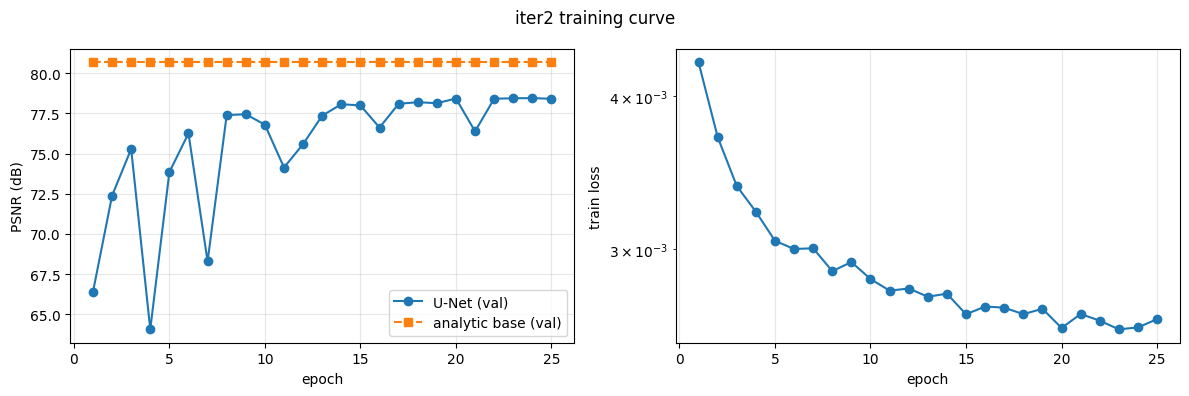

best epoch 24: val 78.449 dB (base 80.674 dB, delta -2.225 dB)


In [26]:
best_ckpt = TRAIN_RUN_DIR / "checkpoints/checkpoint_best.ckpt"
print("best checkpoint:", best_ckpt, "| exists:", best_ckpt.exists())

if TRAIN_HISTORY:
    _ep = [h["epoch"] + 1 for h in TRAIN_HISTORY]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(_ep, [h["val_psnr"] for h in TRAIN_HISTORY], "o-", label="U-Net (val)")
    ax[0].plot(_ep, [h["val_psnr_base"] for h in TRAIN_HISTORY], "s--", label="analytic base (val)")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("PSNR (dB)")
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].semilogy(_ep, [h["loss"] for h in TRAIN_HISTORY], "o-")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("train loss")
    ax[1].grid(alpha=0.3)
    fig.suptitle("iter2 training curve")
    fig.tight_layout()
    plt.show()

    _b = max(TRAIN_HISTORY, key=lambda h: h["val_psnr"])
    print(f"best epoch {_b['epoch'] + 1}: val {_b['val_psnr']:.3f} dB (base {_b['val_psnr_base']:.3f} dB, "
          f"delta {_b['val_psnr'] - _b['val_psnr_base']:+.3f} dB)")

## 17. Test (best checkpoint)

| | 경로 |
|---|---|
| label | `config.test_dataset` |
| measure | `config.test_measure_dir` (없으면 ForwardSimulator 로 즉석 생성) |

**validation 으로 `base` / `net` / `net+TTA` 중 하나를 고르고**, 그 선택을 test 에 적용한다.
analytic 이 이미 상한에 가까운 경우 네트워크가 손해일 수 있으므로 회귀를 막는 안전장치다.


In [27]:
TEST_MAX_FIG: int = 8

TEST_RUN_DIR = globals().get("TRAIN_RUN_DIR")
if TEST_RUN_DIR is None:
    raise RuntimeError("학습 셀을 먼저 실행하거나 TEST_RUN_DIR 을 직접 지정할 것 (예: RUN_DIR / '00000_iter2')")
BEST_CKPT = TEST_RUN_DIR / "checkpoints/checkpoint_best.ckpt"

if config.device is None:
    config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if config.init_time == 0.0:
    config.init_time = time.time()

test_network = load_checkpoint_network(BEST_CKPT, config.device)

test_loader, _, test_len = get_data_wrapper_loader(
    file_path=config.test_dataset,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=config.valid_batch,
        num_workers=config.num_workers,
        shuffle=False,
        measure_path=config.test_measure_dir,
        augment=False,
    ),
)
_vtype = config.valid_data_type if glob.glob(f"{config.valid_dataset[0]}/{config.valid_data_type}") else config.data_type
valid_loader, _, valid_len = get_data_wrapper_loader(
    file_path=config.valid_dataset,
    loader_cfg=LoaderConfig(
        data_type=_vtype, batch=config.valid_batch, num_workers=config.num_workers, shuffle=False, augment=False
    ),
)
print(f"checkpoint : {BEST_CKPT}")
print(f"measure    : {config.test_measure_dir or 'on-the-fly (ForwardSimulator, noise 0)'}")
print(f"test / valid images: {test_len} / {valid_len}")

2026-09-01 05:45:48 [INFO] Loaded checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/checkpoints/checkpoint_best.ckpt
2026-09-01 05:45:48 [INFO] in_chans:6
2026-09-01 05:45:48 [INFO] out_chans:1
2026-09-01 05:45:48 [INFO] chans:24
2026-09-01 05:45:48 [INFO] num_pool_layers:4
checkpoint : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/checkpoints/checkpoint_best.ckpt
measure    : on-the-fly (ForwardSimulator, noise 0)
test / valid images: 100 / 43


In [28]:
# 1) validation 으로 변형 선택
_v_plain, _ = evaluate(valid_loader, test_network, use_tta=False, desc="valid (plain)")
_v_tta, _ = evaluate(valid_loader, test_network, use_tta=True, desc="valid (tta)")

VARIANTS = {
    "analytic base (GCV)": float(_v_plain.mean("psnr_base")),
    "U-Net": float(_v_plain.mean("psnr")),
    "U-Net + flip TTA": float(_v_tta.mean("psnr")),
}
print()
print("[validation 기준 변형 비교]")
for _k, _v in VARIANTS.items():
    print(f"  {_k:<22}{_v:>10.3f} dB")
SELECTED = max(VARIANTS, key=VARIANTS.get)
print(f"-> 선택: {SELECTED}")

# 2) test 평가
_t_plain, _rows_plain = evaluate(test_loader, test_network, use_tta=False, desc="test (plain)")
_t_tta, _rows_tta = evaluate(test_loader, test_network, use_tta=True, desc="test (tta)")

TEST_RESULT = {
    "analytic base (GCV)": (_t_plain.mean("psnr_base"), _t_plain.std("psnr_base"),
                            _t_plain.mean("ssim_base"), _t_plain.std("ssim_base")),
    "U-Net": (_t_plain.mean("psnr"), _t_plain.std("psnr"), _t_plain.mean("ssim"), _t_plain.std("ssim")),
    "U-Net + flip TTA": (_t_tta.mean("psnr"), _t_tta.std("psnr"), _t_tta.mean("ssim"), _t_tta.std("ssim")),
}

print()
print(f"{'method':<24}{'n':>5}{'PSNR':>10}{'PSNR std':>10}{'SSIM':>10}{'SSIM std':>10}")
print("-" * 69)
print(f"{'Measure (input)':<24}{len(_rows_plain):>5}"
      f"{np.mean([r['psnr_in'] for r in _rows_plain]):>10.3f}{'':>10}{'':>10}{'':>10}")
for _k, (_p, _ps, _s, _ss) in TEST_RESULT.items():
    _mark = "  <- selected" if _k == SELECTED else ""
    print(f"{_k:<24}{len(_rows_plain):>5}{_p:>10.3f}{_ps:>10.3f}{_s:>10.4f}{_ss:>10.4f}{_mark}")
print()
print(f"iter1 U-Net           : 25.586 dB / 0.8779   (참고)")
print(f"iter1 Wiener K=1e-4   : 42.251 dB / 0.9881   (참고)")

with open(TEST_RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(
        {
            "selected": SELECTED,
            "valid_variants": VARIANTS,
            "test": {k: list(map(float, v)) for k, v in TEST_RESULT.items()},
            "rows_plain": _rows_plain,
            "rows_tta": _rows_tta,
        },
        f,
        indent=2,
    )

test_png_dir = save_comparison_figures(
    epoch=0,
    data_loader=test_loader,
    network=test_network,
    run_dir=TEST_RUN_DIR,
    max_images=TEST_MAX_FIG,
    subdir="test_png",
    title_prefix="test (best ckpt)",
    use_tta=(SELECTED == "U-Net + flip TTA"),
)
print(f"\nmetrics : {TEST_RUN_DIR / 'test_metrics.json'}")
print(f"figures : {test_png_dir}")

  valid (plain):   0%|          | 0/11 [00:00<?, ?batch/s]

  valid (tta):   0%|          | 0/11 [00:00<?, ?batch/s]


[validation 기준 변형 비교]
  analytic base (GCV)       80.674 dB
  U-Net                     78.449 dB
  U-Net + flip TTA          79.306 dB
-> 선택: analytic base (GCV)


  test (plain):   0%|          | 0/25 [00:00<?, ?batch/s]

  test (tta):   0%|          | 0/25 [00:00<?, ?batch/s]


method                      n      PSNR  PSNR std      SSIM  SSIM std
---------------------------------------------------------------------
Measure (input)           100     7.892                              
analytic base (GCV)       100    80.274     6.830    1.0000    0.0000  <- selected
U-Net                     100    78.013     5.392    1.0000    0.0000
U-Net + flip TTA          100    78.975     5.957    1.0000    0.0000

iter1 U-Net           : 25.586 dB / 0.8779   (참고)
iter1 Wiener K=1e-4   : 42.251 dB / 0.9881   (참고)
2026-09-01 05:46:20 [INFO] Saved 8 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/test_png

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/test_metrics.json
figures : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/test_png


## 18. Conventional method 전체 비교

학습이 필요 없는 방법들과 iter2 U-Net 을 같은 test set 에서 비교한다.
`GCV` 가 붙은 항목은 **label 을 쓰지 않고** 정규화 세기를 정한 것이므로 실제 채점 상황에서도 재현 가능하다.


In [29]:
BASELINE_TKD_CLIP: float = 5.0
BASELINE_FIXED_K: float = 1e-4  # iter1 설정

_rows: list[dict] = []
_samples: list[dict] = []
GRID_MAX: int = 3

test_network.eval()
with torch.no_grad():
    for _data in tqdm(test_loader, desc="conventional", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        measure = _data[DataKey.Measure].to(config.device)
        names = _data[DataKey.Name]

        _gk = gcv_select(measure)
        _glam = gcv_select(measure, mode="grad")
        _net_out, _base = predict(test_network, measure, use_tta=(SELECTED == "U-Net + flip TTA"))

        outs = {
            "measure": measure,
            "tkd": tkd_deconv(measure, clip=BASELINE_TKD_CLIP),
            "wiener_fixed": wiener_deconv(measure, BASELINE_FIXED_K),
            "wiener_gcv": wiener_deconv(measure, _gk),
            "grad_gcv": tikhonov_grad_deconv(measure, _glam),
            "unet": _net_out,
        }
        outs = {k: (v if k == "measure" else v.clamp(0, 1)) for k, v in outs.items()}

        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i]}
            for k, v in outs.items():
                row[f"psnr_{k}"] = calculate_psnr(v[i : i + 1], lab_i).item()
                row[f"ssim_{k}"] = calculate_ssim(v[i : i + 1], lab_i).item()
            _rows.append(row)

            if len(_samples) < GRID_MAX:
                s = {"name": names[i], "metrics": row, "label": lab_i.cpu().numpy().squeeze()}
                for k, v in outs.items():
                    s[k] = v[i : i + 1].cpu().numpy().squeeze()
                _samples.append(s)

METHOD_LABEL = {
    "measure": "Measure (input)",
    "tkd": f"TKD (clip {BASELINE_TKD_CLIP:g})",
    "wiener_fixed": f"Wiener (K={BASELINE_FIXED_K:g}, iter1)",
    "wiener_gcv": "Wiener (K by GCV)",
    "grad_gcv": "grad-Tikhonov (GCV)",
    "unet": f"U-Net iter2 [{SELECTED}]",
}

print()
print(f"{'method':<30}{'n':>5}{'PSNR':>10}{'PSNR std':>10}{'SSIM':>10}{'SSIM std':>10}")
print("-" * 75)
for k, lbl in METHOD_LABEL.items():
    p = [r[f"psnr_{k}"] for r in _rows]
    s = [r[f"ssim_{k}"] for r in _rows]
    print(f"{lbl:<30}{len(_rows):>5}{np.mean(p):>10.3f}{np.std(p, ddof=1):>10.3f}"
          f"{np.mean(s):>10.4f}{np.std(s, ddof=1):>10.4f}")

print()
print("[iter1 대비]")
_i1_unet, _i1_wiener = 25.586, 42.251
_best_now = max(np.mean([r[f"psnr_{k}"] for r in _rows]) for k in METHOD_LABEL if k != "measure")
print(f"  iter1 최고 (Wiener K=1e-4) : {_i1_wiener:8.3f} dB")
print(f"  iter1 U-Net               : {_i1_unet:8.3f} dB")
print(f"  iter2 최고                : {_best_now:8.3f} dB  ({_best_now - _i1_wiener:+.3f} dB vs iter1 최고, "
      f"{_best_now - _i1_unet:+.3f} dB vs iter1 U-Net)")

with open(TEST_RUN_DIR / "baseline_metrics.json", "w") as f:
    json.dump(_rows, f, indent=2)
print(f"\nmetrics : {TEST_RUN_DIR / 'baseline_metrics.json'}")

conventional:   0%|          | 0/25 [00:00<?, ?batch/s]


method                            n      PSNR  PSNR std      SSIM  SSIM std
---------------------------------------------------------------------------
Measure (input)                 100     7.892     1.949    0.0318    0.2124
TKD (clip 5)                    100    31.221     5.565    0.9348    0.0552
Wiener (K=0.0001, iter1)        100    42.262     5.657    0.9882    0.0222
Wiener (K by GCV)               100    80.274     6.830    1.0000    0.0000
grad-Tikhonov (GCV)             100    83.902     7.227    1.0000    0.0000
U-Net iter2 [analytic base (GCV)]  100    78.013     5.392    1.0000    0.0000

[iter1 대비]
  iter1 최고 (Wiener K=1e-4) :   42.251 dB
  iter1 U-Net               :   25.586 dB
  iter2 최고                :   83.902 dB  (+41.651 dB vs iter1 최고, +58.316 dB vs iter1 U-Net)

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/baseline_metrics.json


### 비교 그림

행 = test 영상, 열 = 복원 결과와 상대 오차율(%) 맵.


saved: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_deconvolution_iter2/00001_iter2/baseline_grid.png


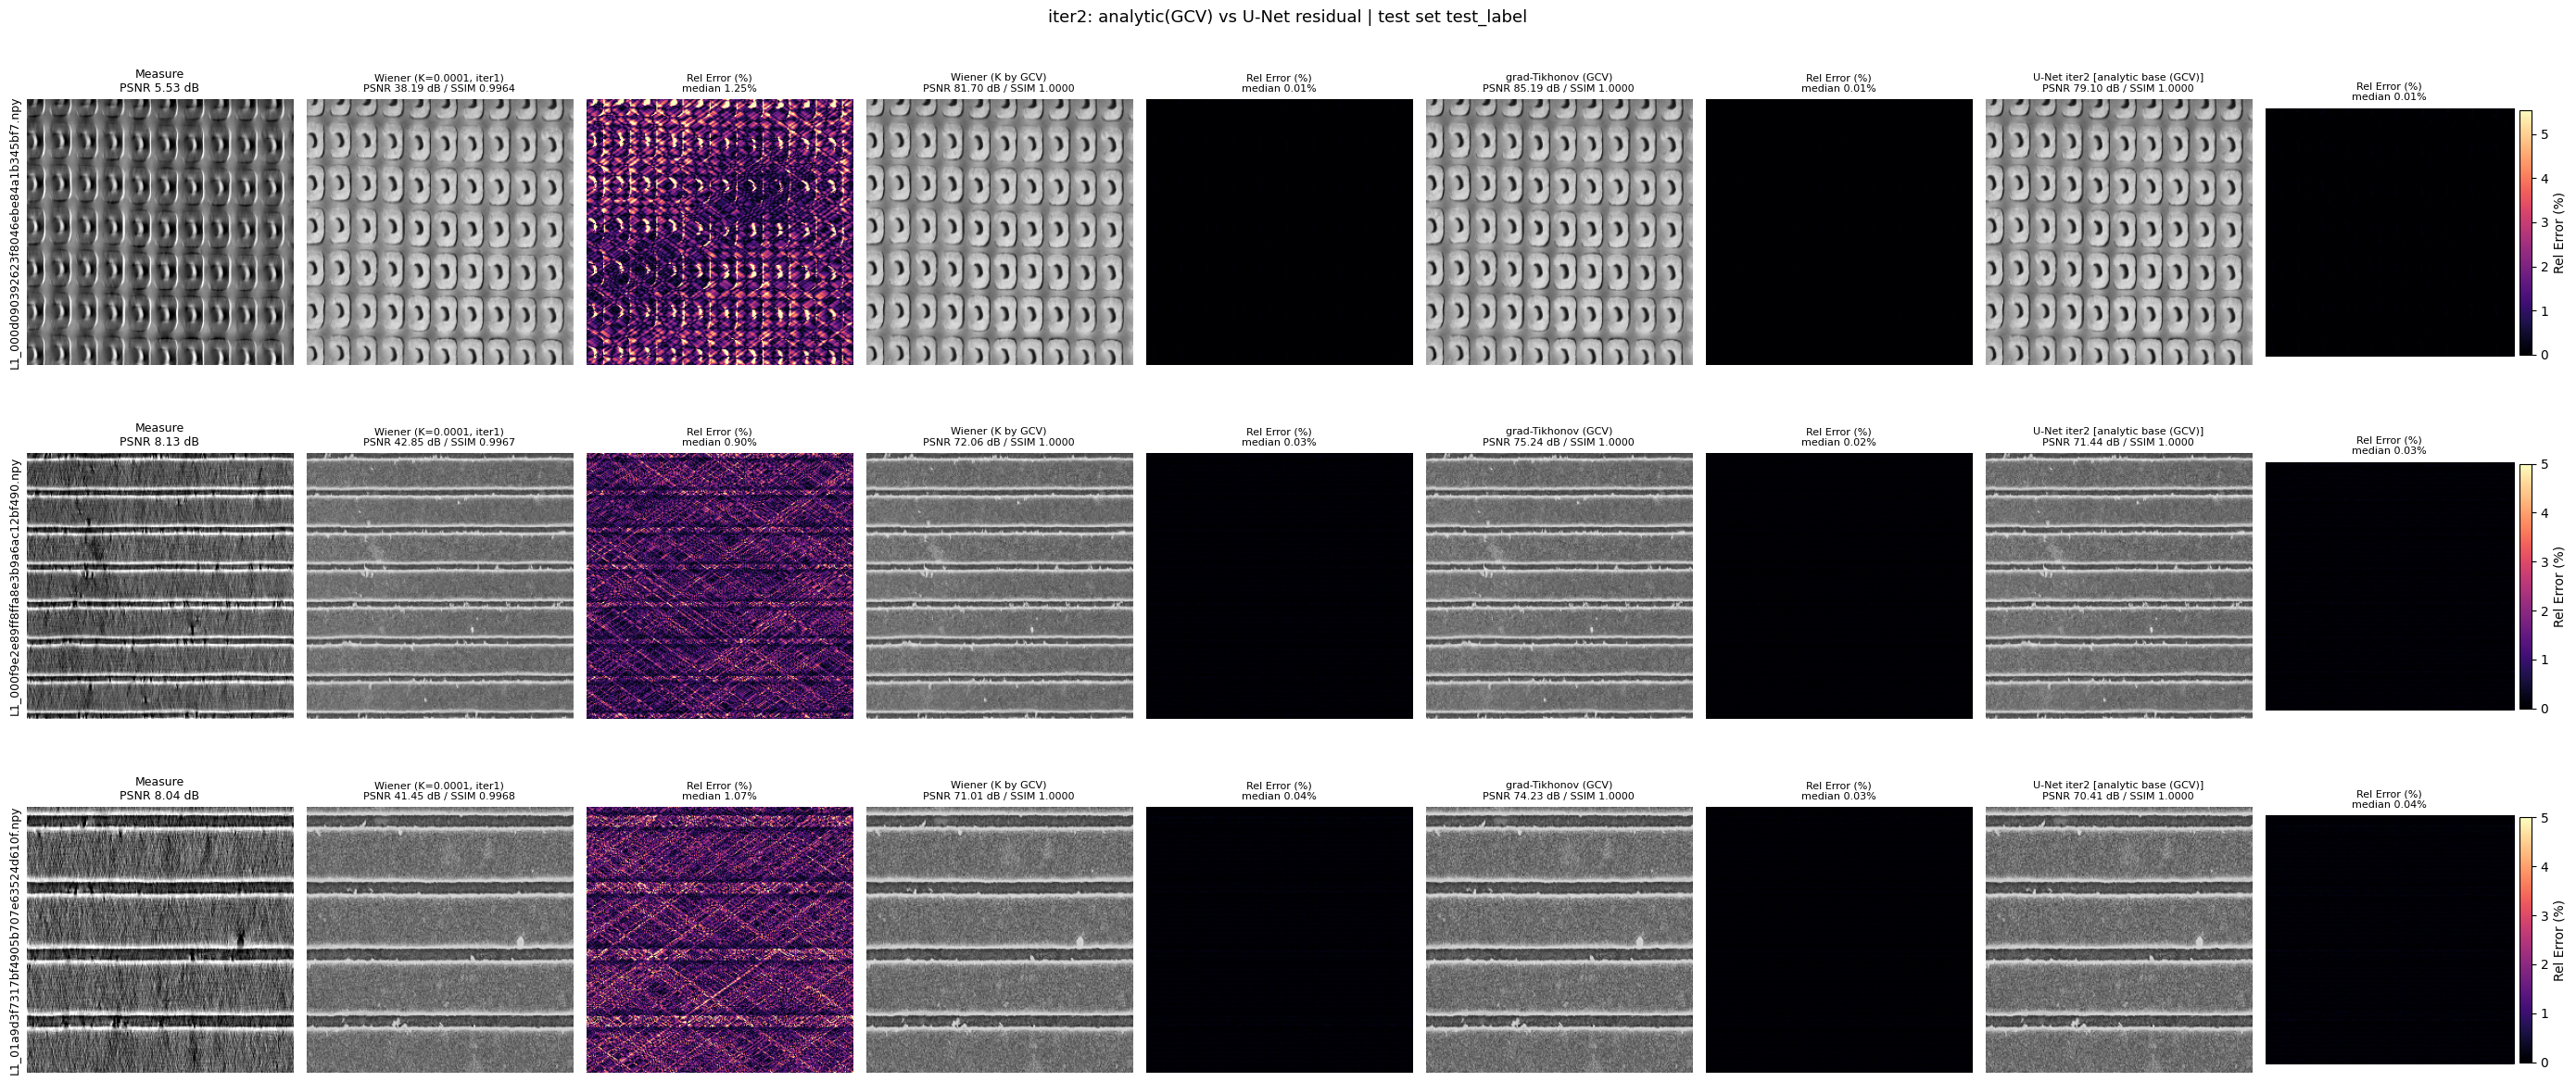

In [30]:
ERROR_CMAP = "magma"
GRID_COLS = ["wiener_fixed", "wiener_gcv", "grad_gcv", "unet"]

if not _samples:
    raise RuntimeError("_samples 가 비어 있다. 앞의 conventional 비교 셀을 먼저 실행할 것")

n_col = 1 + 2 * len(GRID_COLS)
fig, axes = plt.subplots(len(_samples), n_col, figsize=(3.1 * n_col, 4.0 * len(_samples)))
axes = np.asarray(axes).reshape(len(_samples), n_col)

for r, sample in enumerate(_samples):
    lab = sample["label"]
    metrics = sample["metrics"]
    vmax = float(np.percentile(lab, 98) * 1.2)
    eps = 1e-4
    rel = {k: np.abs(sample[k] - lab) / (np.abs(lab) + eps) * 100.0 for k in GRID_COLS}
    err_vmax = float(max(np.percentile(np.stack(list(rel.values())), 99), 5.0))

    mea = sample["measure"]
    ax = axes[r, 0]
    ax.imshow(mea, cmap="gray", vmin=float(np.percentile(mea, 1)), vmax=float(np.percentile(mea, 99)))
    ax.set_title(f"Measure\nPSNR {metrics['psnr_measure']:.2f} dB", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_ylabel(sample["name"], fontsize=9)

    for c, key in enumerate(GRID_COLS):
        ax = axes[r, 1 + 2 * c]
        ax.imshow(sample[key], cmap="gray", vmin=0.0, vmax=vmax)
        ax.set_title(f"{METHOD_LABEL[key]}\nPSNR {metrics[f'psnr_{key}']:.2f} dB / "
                     f"SSIM {metrics[f'ssim_{key}']:.4f}", fontsize=8)
        ax.axis("off")

        ax_err = axes[r, 2 + 2 * c]
        im = ax_err.imshow(rel[key], cmap=ERROR_CMAP, vmin=0.0, vmax=err_vmax)
        ax_err.set_title(f"Rel Error (%)\nmedian {np.median(rel[key]):.2f}%", fontsize=8)
        ax_err.axis("off")

    fig.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.02, label="Rel Error (%)")

fig.suptitle(f"iter2: analytic(GCV) vs U-Net residual | test set {Path(config.test_dataset[0]).name}", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.subplots_adjust(hspace=0.22)

grid_path = TEST_RUN_DIR / "baseline_grid.png"
fig.savefig(grid_path, dpi=140, bbox_inches="tight")
print(f"saved: {grid_path}")
plt.show()